In [206]:
import pandas as pd
import numpy as np

In [207]:
######## Variables ############

years = [2025,2030,2040,2050]

In [ ]:
### DEFINE BETA VALUES FOR VDF

vot_growth = 0.015

beta_vals = {} # TBD: compute values based on growth

beta_template_aux = {
    "Period": ["AM", "MD", "PM", "NT"],
    1: [3.820, 3.823, 4.005, 4.009], # [4.155, 4.136, 4.135, 4.103],
    2: [0.715, 0.708, 0.592, 0.708]
}

beta_vals_aux = pd.DataFrame(beta_template_aux)

beta_vals_aux.set_index("Period", inplace=True)

beta_vals[2025] = beta_vals_aux.copy()

beta_vals_aux[1] = beta_vals_aux[1] * (1 + vot_growth) ** (2030-2025)

beta_vals[2030] = beta_vals_aux.copy()

beta_vals_aux[1] = beta_vals_aux[1] * (1 + vot_growth) ** (2040-2030)

beta_vals[2040] = beta_vals_aux.copy()

beta_vals_aux[1] = beta_vals_aux[1] * (1 + vot_growth) ** (2050-2040)

beta_vals[2050] = beta_vals_aux.copy()

beta_vals

{2025:             1      2
 Period              
 AM      4.155  0.715
 MD      4.136  0.708
 PM      4.135  0.592
 NT      4.103  0.708,
 2030:                1      2
 Period                 
 AM      4.476115  0.715
 MD      4.455647  0.708
 PM      4.454569  0.592
 NT      4.420096  0.708,
 2040:                1      2
 Period                 
 AM      5.194714  0.715
 MD      5.170960  0.708
 PM      5.169710  0.592
 NT      5.129702  0.708,
 2050:                1      2
 Period                 
 AM      6.028678  0.715
 MD      6.001110  0.708
 PM      5.999659  0.592
 NT      5.953229  0.708}

In [209]:
### DEFINE LOOKUP TABLE FOR BONUS PER PERIOD

lookup_period_file = r"inputs/LookUp_Period.csv"

lookup_period = pd.read_csv(
    lookup_period_file,
    sep=",",          # `delimiter` y `sep` son equivalentes; elige uno
    encoding="utf-8",
    decimal=".",      # parsea decimales con punto
    thousands=",",    # parsea separador de miles con coma
    quotechar='"',
    index_col=0
)

# Clip y reasignar
lookup_period = lookup_period*0

In [210]:
### DEFINE SEGMENT PARAMETERS
# Default configuration for time periods in traffic data

# TBD: Correctly assess the hard_cap, how does the soft cap work?
# year_soft_cap = [3.9 / 2, 4.75 / 2, 6.08 / 2]

#year_soft_cap = [3.9 / 2, 3.9 / 2, 3.9 / 2]

#TBD: Make this automatically
period_template = [                 # (Period, Hours/Day, Peak/OP, 4Periods tag)
    ("Night",        8, "OP",   "NT"),
    ("AM-Early",     1, "OP",   "AM"),
    ("AM-Peak",      2, "Peak", "AM"),
    ("AM-Shoulder",  1, "OP",   "AM"),
    ("MD",           5, "OP",   "MD"),
    ("PM-Shoulder",  1, "OP",   "PM"),
    ("PM-Peak",      3, "Peak", "PM"),
    ("PM-Late",      3, "OP",   "PM"),
]

rows = []
years = [2025, 2030, 2040, 2050]

# Default time periods list (for reference)
default_time_periods = [
    "Night",
    "AM-Early",
    "AM-Peak",
    "AM-Shoulder",
    "MD",
    "PM-Shoulder",
    "PM-Peak",
    "PM-Late"
]

# Create the base scenario: hour -> time period mapping
hour_to_period = {
    0: "Night",
    1: "Night",
    2: "Night",
    3: "Night",
    4: "Night",
    5: "Night",
    6: "AM-Early",
    7: "AM-Peak",
    8: "AM-Peak",
    9: "AM-Shoulder",
    10: "MD",
    11: "MD",
    12: "MD",
    13: "MD",
    14: "MD",
    15: "PM-Shoulder",
    16: "PM-Peak",
    17: "PM-Peak",
    18: "PM-Peak",
    19: "PM-Late",
    20: "PM-Late",
    21: "PM-Late",
    22: "Night",
    23: "Night"
}

period_to_period = {
    'Evening': 'Night',
    'Evening': 'PM-Late',
    'EarlyAM': 'AM-Early',
    'AM': 'AM-Peak',
    'AM': 'AM-Shoulder',
    'Midday': 'MD',
    'Midday': 'PM-Shoulder',
    'PM': 'PM-Peak'
}

# Define the segments and their parameters

awt_adt = 1.1 # Average weekday traffic (AWT) to average daily traffic (ADT) ratio
peak_factor = 1 # 1.05 # Peak factor for adjustment at peak hour traffic

hov_percentage = pd.DataFrame({
    'Year' : [2025,2030,2040,2050],
    'HOV percentage' : [0.02,0.03,0.04,0.05]
})

hov_percentage.set_index('Year', inplace=True)


"""
S1: Chamblee - I 285
S2: I 285 - Jimmy
S3: Jimmy - Indian Trail
S4: Indian Trail -  GA-316
S5: GA-316 - Old Peachtree
S6: Old Peachtree - I-985
S7: I-985 - Hamilton Mill
"""

lengths = [3,3,2.2,2.2,3.4,3.4,4.4,4.4,3,3,4.4,4.4,5.6,5.6]
inscope = [0.75]*10 + [0.65]*4

# Define segment parameters base
seg_params = pd.DataFrame({
    'SegDir':   ["1NB","1SB","2NB","2SB","3NB","3SB","4NB","4SB","5NB","5SB","6NB","6SB","7NB","7SB"],
    'Length':    lengths,
    'Inscope':   inscope,
    'Lanes_GP': [6,6,6,6,6,6,6,6,4,4,4,4,3,3],# [5,6,6,6,6,5,6,6,4,4,4,4,3,3], # We may need to sum the toll lane
    'Lanes_ML':  [1]*14,
    'CapPerLane_GP': [2000]*14,
    'CapPerLane_ML': [1800]*14,
    'Speed_GP':  [70]*2 + [70]*6 + [70]*6,
    'Speed_ML':  [75]*14,
    'Alpha_GP':  [1.6]*14,
    'Beta_GP':   [6.5,5]*7,
    'Alpha_ML':  [1]*14,
    'Beta_ML':   [4]*14,
    'Min_Toll_2016': [None]*14,
    'Max_Toll_2016': [None]*14,
    'LanesGP_AM_Peak': [5]*14,
    'LanesGP_PM_Peak': [5]*14,
})

seg_params.set_index('SegDir', inplace=True)

# Compute capacities as lanes * cap per lane
seg_params['Cap_GP'] = seg_params['Lanes_GP'] * seg_params['CapPerLane_GP']
seg_params['Cap_ML'] = seg_params['Lanes_ML'] * seg_params['CapPerLane_ML']

# Compute peak capacities as Alpha * base capacity
seg_params['CapGP_Peak'] = seg_params['Alpha_GP'] * seg_params['Cap_GP']
seg_params['CapML_Peak'] = seg_params['Alpha_ML'] * seg_params['Cap_ML']

# Optional: if you want integer capacities
seg_params[['Cap_GP','Cap_ML','CapGP_Peak','CapML_Peak']] = seg_params[
    ['Cap_GP','Cap_ML','CapGP_Peak','CapML_Peak']
].astype(int)

# Preview
seg_params

,Length,Inscope,Lanes_GP,Lanes_ML,CapPerLane_GP,CapPerLane_ML,Speed_GP,Speed_ML,Alpha_GP,Beta_GP,Alpha_ML,Beta_ML,Min_Toll_2016,Max_Toll_2016,LanesGP_AM_Peak,LanesGP_PM_Peak,Cap_GP,Cap_ML,CapGP_Peak,CapML_Peak
SegDir,,,,,,,,,,,,,,,,,,,,
1NB,3.0,0.75,6,1,2000,1800,70,75,1.6,6.5,1,4,None,None,5,5,12000,1800,19200,1800
1SB,3.0,0.75,6,1,2000,1800,70,75,1.6,5.0,1,4,None,None,5,5,12000,1800,19200,1800
2NB,2.2,0.75,6,1,2000,1800,70,75,1.6,6.5,1,4,None,None,5,5,12000,1800,19200,1800
2SB,2.2,0.75,6,1,2000,1800,70,75,1.6,5.0,1,4,None,None,5,5,12000,1800,19200,1800
3NB,3.4,0.75,6,1,2000,1800,70,75,1.6,6.5,1,4,None,None,5,5,12000,1800,19200,1800
3SB,3.4,0.75,6,1,2000,1800,70,75,1.6,5.0,1,4,None,None,5,5,12000,1800,19200,1800
4NB,4.4,0.75,6,1,2000,1800,70,75,1.6,6.5,1,4,None,None,5,5,12000,1800,19200,1800
4SB,4.4,0.75,6,1,2000,1800,70,75,1.6,5.0,1,4,None,None,5,5,12000,1800,19200,1800
5NB,3.0,0.75,4,1,2000,1800,70,75,1.6,6.5,1,4,None,None,5,5,8000,1800,12800,1800


In [211]:
# SET CAPACITY FACTORS FOR EACH SEGMENT AND PERIOD
capacity_factors_file = 'inputs/capacity_factors.csv'

capacity_factors_data = pd.read_csv(capacity_factors_file,
    sep=",",          # `delimiter` y `sep` son equivalentes; elige uno
    encoding="utf-8",
    decimal=".",      # parsea decimales con punto
    thousands=",",    # parsea separador de miles con coma
    quotechar='"',
    index_col=0
)

# Create DF from your original data
df_cf = capacity_factors_data
# Set 'SegDir' as index
# df_cf.set_index('SegDir', inplace=True)

df_cf = df_cf.clip(lower=0.2, upper=1.8)
#Lower upper limit changed to 1.0
# Transpose matrix to make the calculation

cap_adj = seg_params['Cap_GP'] * df_cf

df_cf

,1NB,1SB,2NB,2SB,3NB,3SB,4NB,4SB,5NB,5SB,6NB,6SB,7NB,7SB
Period,,,,,,,,,,,,,,
AM-Early,0.978242,1.800000,1.000000,1.000000,1.000000,1.000000,1.000000,0.83435,1.000000,0.788572,1.000000,1.0,0.764468,1.000000
AM-Peak,1.110741,1.219830,1.000000,1.000000,1.757155,1.000000,1.621945,1.00000,1.691982,0.863529,1.000000,1.0,1.000000,1.000000
AM-Shoulder,1.277913,1.397559,1.000000,1.000000,1.800000,1.000000,1.800000,0.99725,1.590133,0.746496,1.000000,1.0,1.000000,1.000000
MD,1.357335,1.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.743746,1.800000,1.000000,1.0,1.000000,1.000000
Night,1.000000,1.000000,1.000000,1.055085,1.000000,1.097384,1.000000,1.01368,1.000000,1.000000,0.993309,1.0,0.631960,0.921083
PM-Late,1.000000,1.800000,1.000000,1.800000,1.000000,1.800000,1.000000,1.80000,1.752980,1.800000,1.000000,1.0,1.000000,1.000000
PM-Peak,0.859577,1.800000,0.909283,1.800000,1.000000,1.000000,1.000000,1.00000,1.000000,1.800000,0.923096,1.0,1.000000,1.000000
PM-Shoulder,0.984931,1.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.800000,1.800000,0.933042,1.0,1.000000,1.000000


In [212]:
# SET CAPACITY FACTORS FOR EACH SEGMENT AND PERIOD
pce_factors_file = 'inputs/pce_factors.csv'

pce_factors_data = pd.read_csv(pce_factors_file,
    sep=",",          # `delimiter` y `sep` son equivalentes; elige uno
    encoding="utf-8",
    decimal=".",      # parsea decimales con punto
    thousands=",",    # parsea separador de miles con coma
    quotechar='"',
    index_col=0
)

# Create DF from your original data
df_cf = pce_factors_data
# Set 'SegDir' as index
# df_cf.set_index('SegDir', inplace=True)

#Lower upper limit changed to 1.0
# Transpose matrix to make the calculation

pce_adj = df_cf

pce_adj

,1NB,1SB,2NB,2SB,3NB,3SB,4NB,4SB,5NB,5SB,6NB,6SB,7NB,7SB
Period,,,,,,,,,,,,,,
AM-Early,1.200000,0.600000,0.732417,0.862688,0.703953,0.928558,0.762905,1.200000,0.676237,1.200000,0.692619,0.299180,1.000000,0.344315
AM-Peak,0.600000,0.600000,0.682594,0.819743,0.600000,0.846006,0.600000,1.136691,0.600000,1.200000,0.363203,0.932390,0.812781,0.230275
AM-Shoulder,0.600000,0.600000,0.697839,0.879618,0.600000,0.904733,0.600000,1.200000,0.600000,1.200000,0.386439,0.321604,0.687480,0.237381
MD,0.600000,0.600000,0.889251,0.832731,0.810345,0.751670,0.657606,0.873811,0.600000,0.600000,0.679424,0.233112,0.477204,0.300192
Night,1.009251,0.898014,0.701720,0.600000,0.674666,0.600000,0.731034,0.600000,0.982294,0.691019,1.000000,0.707497,1.000000,1.000000
PM-Late,0.968513,0.600000,1.003695,0.600000,0.875903,0.600000,0.667195,0.600000,0.600000,0.600000,0.350441,0.252989,0.420108,0.378831
PM-Peak,1.200000,0.600000,1.200000,0.600000,1.154110,0.729857,1.022637,0.875992,0.842278,0.600000,1.000000,0.210202,0.777450,0.302790
PM-Shoulder,1.200000,0.600000,1.086029,1.022729,0.969457,1.052437,0.867376,1.077979,0.600000,0.600000,1.000000,0.224988,0.372532,0.290698


In [213]:
### IMPORT GROWTHS FOR EACH SEGMENT AND PERIOD
file_path_tolls = r"inputs/tolls.csv"
base_tolls = pd.read_csv(
    file_path_tolls,
    delimiter=',',
    encoding='utf-8',
    decimal='.',        # ← this tells pandas how to parse decimals
    thousands=',',       # ← this tells pandas how to parse thousands
    quotechar='"'
)

base_tolls = base_tolls.set_index('Period')

# base_tolls.loc['Night', 'NB']

base_tolls

,1NB,1SB,2NB,2SB,3NB,3SB,4NB,4SB,5NB,5SB,6NB,6SB,7NB,7SB
Period,,,,,,,,,,,,,,
Night,0.117778,0.1,0.117778,0.147646,0.117778,0.147646,0.117778,0.147646,0.1,0.147646,0.1,0.1,0.1,0.1
AM-Early,0.169543,0.1,0.169543,0.795370,0.169543,0.795370,0.169543,0.795370,0.1,0.795370,0.1,0.1,0.1,0.1
AM-Peak,0.167837,0.5,0.167837,1.233789,0.167837,1.233789,0.167837,1.233789,0.1,1.233789,0.1,0.5,0.1,0.5
AM-Shoulder,0.174664,0.5,0.174664,0.683612,0.174664,0.683612,0.174664,0.683612,0.1,0.683612,0.1,0.1,0.1,0.1
MD,0.415253,0.1,0.415253,0.188472,0.415253,0.188472,0.415253,0.188472,0.1,0.188472,0.1,0.1,0.1,0.1
PM-Shoulder,1.419297,0.1,1.419297,0.186849,1.419297,0.186849,1.419297,0.186849,0.1,0.186849,0.1,0.1,0.1,0.1
PM-Peak,1.202351,0.1,1.202351,0.212310,1.202351,0.212310,1.202351,0.212310,0.5,0.212310,0.5,0.1,0.5,0.1
PM-Late,0.187399,0.1,0.187399,0.163716,0.187399,0.163716,0.187399,0.163716,0.1,0.163716,0.1,0.1,0.1,0.1


In [214]:
import numpy as np

def adjusted_cumprod(row, target_year, multiplier):
    years = row.index
    print(row.values)
    factors = 1 + row.values
    
    # Find the index of the target year
    target_idx = list(years).index(target_year)
    
    # Apply multiplier to the target year's factor
    factors[target_idx] *= multiplier
    
    # Calculate cumulative product
    return pd.Series(np.cumprod(factors), index=years)

In [215]:
### IMPORT GROWTHS FOR EACH CLASS
file_path_growths = r"inputs/growths_per_segment_lights.csv"
base_growth_df = pd.read_csv(
    file_path_growths,
    delimiter=',',
    encoding='utf-8',
    decimal='.',        # ← this tells pandas how to parse decimals
    thousands=',',       # ← this tells pandas how to parse thousands
    quotechar='"'
)

base_growth_df = base_growth_df.iloc[:, 1:]
project_years = base_growth_df.columns[1:].tolist()

base_growth_df.iloc[:, 1:] = base_growth_df.iloc[:, 1:]

base_growth_df.iloc[:, 1:] =  base_growth_df.iloc[:, 1:] + 1

# base_growth_df.loc[0, '2030'] *= 1.05 # S1
# base_growth_df.loc[1, '2030'] *= 1.05 # S2
# base_growth_df.loc[2, '2030'] *= 1.05 # S3
# base_growth_df.loc[3, '2030'] *= 1.05 # S4
# base_growth_df.loc[9, '2030'] *= 1.05 # S10

# base_growth_df.loc[:, '2030'] *= 1.11

# base_growth_df.loc[11, '2030'] *= 1.05/1.11 # S12

base_growth_df.to_csv('growth_test.csv')

base_growth_df

,SegmentMapped,2025,2026,2027,2028,2029,2030,2031,2032,2033,...,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054
0,S1,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
1,S2,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
2,S3,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
3,S4,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
4,S5,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
5,S6,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
6,S7,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [216]:
### IMPORT GROWTHS FOR EACH CLASS
file_path_growths = r"inputs/growths_per_segment_medium.csv"
base_growth_df_medium = pd.read_csv(
    file_path_growths,
    delimiter=',',
    encoding='utf-8',
    decimal='.',        # ← this tells pandas how to parse decimals
    thousands=',',       # ← this tells pandas how to parse thousands
    quotechar='"'
)

base_growth_df_medium = base_growth_df_medium.iloc[:, 1:]
project_years = base_growth_df_medium.columns[1:].tolist()

base_growth_df_medium.iloc[:, 1:] = base_growth_df_medium.iloc[:, 1:]

base_growth_df_medium.iloc[:, 1:] =  base_growth_df_medium.iloc[:, 1:] + 1

# base_growth_df_medium.loc[:, '2030'] *= 1.05

base_growth_df_medium

,SegmentMapped,2025,2026,2027,2028,2029,2030,2031,2032,2033,...,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054
0,S1,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
1,S2,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
2,S3,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
3,S4,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
4,S5,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
5,S6,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
6,S7,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
### IMPORT GROWTHS FOR EACH CLASS
file_path_growths = r"inputs/growths_per_segment_heavy.csv"
base_growth_df_heavy = pd.read_csv(
    file_path_growths,
    delimiter=',',
    encoding='utf-8',
    decimal='.',        # ← this tells pandas how to parse decimals
    thousands=',',       # ← this tells pandas how to parse thousands
    quotechar='"'
)

base_growth_df_heavy = base_growth_df_heavy.iloc[:, 1:]
project_years = base_growth_df_heavy.columns[1:].tolist()

base_growth_df_heavy.iloc[:, 1:] = base_growth_df_heavy.iloc[:, 1:]

base_growth_df_heavy.iloc[:, 1:] =  base_growth_df_heavy.iloc[:, 1:] + 1

# base_growth_df_heavy.loc[:, '2030'] *= 1.05

base_growth_df_heavy

,SegmentMapped,2025,2026,2027,2028,2029,2030,2031,2032,2033,...,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054
0,S1,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
1,S2,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
2,S3,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
3,S4,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
4,S5,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
5,S6,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
6,S7,1.0,1.01,1.01,1.01,1.01,1.01,1.008,1.008,1.008,...,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006,1.006
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [218]:
### IMPORT COUNTS AND SEPARATE BY CLASS AND PERIODS

file_path_counts = r"inputs/counts_by_hour_grouped_sorted.csv"
base_counts_df = pd.read_csv(
    file_path_counts,
    delimiter=',',
    encoding='utf-8',
    decimal='.',        # ← this tells pandas how to parse decimals
    thousands=',',       # ← this tells pandas how to parse thousands
    quotechar='"'
)

# --- Ajustar direcciones ---
base_counts_df["Direction"] = base_counts_df["Direction"].replace({"SB": "SB", "NB": "NB"})

# --- Crear columna Seg/Dir ---
base_counts_df["Seg/Dir"] = base_counts_df["Segment"].astype(str) + base_counts_df["Direction"]

# --- Función para procesar cada clase ---
def process_class(df_class):
    # Convertir a formato largo
    df_long = df_class.melt(
        id_vars=["Seg/Dir", "Segment", "Direction", "Class"],
        value_vars=[str(h) for h in range(24)],
        var_name="Hour",
        value_name="Volume"
    )
    
    # Mapear hora a periodo
    df_long["Hour"] = df_long["Hour"].astype(int)
    df_long["Period"] = df_long["Hour"].map(hour_to_period)
    
    # Agregar por Segment/Direction/Class/Period
    df_period = df_long.groupby(
        ["Seg/Dir", "Segment", "Direction", "Class", "Period"], as_index=False, sort=False
    ).agg({"Volume": "mean"}).round(0)
    
    # Pivot a formato ancho (periodos como columnas)
    period_order = df_period['Period'].unique()
    df_wide = df_period.pivot(
        index=["Seg/Dir", "Segment", "Direction", "Class"],
        columns="Period",
        values="Volume"
    )[period_order].reset_index()
    
    # Mantener solo Seg/Dir como índice
    df_proc = df_wide.drop(columns=["Class", "Direction", "Segment"]).set_index("Seg/Dir")
    
    return df_proc

# --- Separar por clases y procesar ---
dfs_by_class = {}
for cls in base_counts_df["Class"].unique():
    df_cls = base_counts_df[base_counts_df["Class"] == cls].copy()
    dfs_by_class[cls] = process_class(df_cls)


'''
Vehicle Classifications follow FHWA standards:
Lights: FHWA Classes 1-3 [Light Duty Vehicles]
Medium A: Classes 4-5 [Buses and Single Unit 2 axles trucks] 
Medium B: Class 6-7 [Single Unit 3 or 4 axles Trucks]
Heavy A: Classes 8-10 [Single Trailer 3 or more axles trucks]
Heavy B: Classes 11-13 [Combination Trucks Multitrailer Trucks]
'''

# --- Ejemplo de uso ---
df_lights = dfs_by_class["Lights"]
df_mediumA = dfs_by_class["Medium A"]
df_mediumB = dfs_by_class["Medium B"]
df_heavyA = dfs_by_class["Heavy A"]
df_heavyB = dfs_by_class["Heavy B"]

df_lights


Period,Night,AM-Early,AM-Peak,AM-Shoulder,MD,PM-Shoulder,PM-Peak,PM-Late
Seg/Dir,,,,,,,,
S1NB,2238.0,1841.0,4183.0,4812.0,5111.0,6757.0,6670.0,6393.0
S1SB,1637.0,4573.0,7757.0,7826.0,5968.0,4858.0,6246.0,4575.0
S2NB,3220.0,3086.0,6362.0,7274.0,7621.0,8273.0,7207.0,7436.0
S2SB,2585.0,6971.0,9309.0,8274.0,7694.0,5126.0,7001.0,6368.0
S3NB,3349.0,3209.0,6617.0,7565.0,7925.0,8604.0,7495.0,7734.0
S3SB,2688.0,7250.0,9681.0,8605.0,8002.0,5331.0,7281.0,6623.0
S4NB,3091.0,2962.0,6108.0,6983.0,7316.0,7941.0,6919.0,7138.0
S4SB,2482.0,6693.0,8936.0,7943.0,7386.0,4922.0,6721.0,6114.0
S5NB,1592.0,2313.0,4412.0,4147.0,4546.0,5076.0,5606.0,4570.0


In [219]:
# --- Lista de periodos según tus columnas ---
period_cols = ["Night","AM-Early","AM-Peak","AM-Shoulder","MD","PM-Shoulder","PM-Peak","PM-Late"]

# Diccionario de dataframes por clase
class_dfs = {
    "Lights": df_lights,
    "MediumA": df_mediumA,
    "MediumB": df_mediumB,
    "HeavyA": df_heavyA,
    "HeavyB": df_heavyB
}

projected_long_by_class = {}

for cls_name, df_class in class_dfs.items():
    df = df_class.copy()
    
    # Resetear índice Seg/Dir y extraer Segment y Direction
    df = df.reset_index()
    df["Segment"] = df["Seg/Dir"].str.extract(r"(\d+)")[0]    # solo los números
    df["Direction"] = df["Seg/Dir"].str.extract(r"([A-Z]+)")[0]  # solo las letras
    df["Class"] = cls_name
    
    # Melt usando las columnas de periodos
    df_long = df.melt(
        id_vars=["Seg/Dir","Segment","Direction","Class"],
        value_vars=period_cols,
        var_name="Period",
        value_name="AADT "+df["Class"][0]
    )
    
    # Normalizar SegDir (opcional)
    df_long["SegDir"] = df_long["Seg/Dir"].str.strip().str.upper().str.lstrip("S")
    
    projected_long_by_class[cls_name] = df_long

# Ejemplo: ver Lights
projected_long_lights_df = projected_long_by_class["Lights"]
projected_long_mediumA_df = projected_long_by_class["MediumA"]
projected_long_mediumB_df = projected_long_by_class["MediumB"]
projected_long_heaviesA_df = projected_long_by_class["HeavyA"]
projected_long_heaviesB_df = projected_long_by_class["HeavyB"]
projected_long_mediumA_df


,Seg/Dir,Segment,Direction,Class,Period,AADT MediumA,SegDir
0,S1NB,1,S,MediumA,Night,0.0,1NB
1,S1SB,1,S,MediumA,Night,0.0,1SB
2,S2NB,2,S,MediumA,Night,0.0,2NB
3,S2SB,2,S,MediumA,Night,0.0,2SB
4,S3NB,3,S,MediumA,Night,0.0,3NB
...,...,...,...,...,...,...,...
107,S5SB,5,S,MediumA,PM-Late,0.0,5SB
108,S6NB,6,S,MediumA,PM-Late,0.0,6NB
109,S6SB,6,S,MediumA,PM-Late,0.0,6SB
110,S7NB,7,S,MediumA,PM-Late,0.0,7NB


In [220]:
rows = []

for year in years:
    for seg in seg_params.index:  # e.g., "1NB", "1SB", etc.
        seg_data = seg_params.loc[seg]
        # Extraer parte numérica y dirección
        seg_numeric = ''.join(filter(str.isdigit, seg))  # e.g., "10"
        direction = seg[len(seg_numeric):]       
        for p, hrs, peak, tag in period_template:
            rows.append({
                "Year": year,
                "SegDir": seg,
                "Segment": seg_numeric,        
                "Direction": direction,     
                "Period": p,
                "Hours/Day": hrs,
                "Peak": peak,
                "4Periods": tag,

                # Parámetros técnicos
                "Length": seg_data["Length"],
                "Speed GP": seg_data["Speed_GP"],
                "Capacity GP": seg_data["CapPerLane_GP"] * seg_data["Lanes_GP"],
                "Alpha GP": seg_data["Alpha_GP"],
                "Beta GP": seg_data["Beta_GP"],
                "Speed ML": seg_data["Speed_ML"],
                "Capacity ML": seg_data["CapPerLane_ML"] * seg_data["Lanes_ML"],
                "Alpha ML": seg_data["Alpha_ML"],
                "Beta ML": seg_data["Beta_ML"],
                "MinToll": 0.05,
                "MinCapture": 0.01
            })

# --- plantilla base ---
first_model_df = pd.DataFrame(rows)

# --- merge para todas las clases ---
for cls_name, df_proj in projected_long_by_class.items():
    proj_merge_df = df_proj[["SegDir", "Period", f"AADT {cls_name}"]].copy()
    proj_merge_df.rename(columns={"AADT": f"AADT {cls_name}"}, inplace=True)

    first_model_df = first_model_df.merge(
        proj_merge_df,
        on=["SegDir", "Period"],
        how="left"
    )

# --- 1. Reshape growths a formato largo ---
growths_long = base_growth_df.melt(
    id_vars="SegmentMapped",
    var_name="Year",
    value_name="AnnualGrowth"
).copy()
growths_long["Year"] = growths_long["Year"].astype(int)

# --- 2. Calcular crecimiento acumulado desde 2025 ---
# Ordenamos por año y aplicamos cumprod
growths_long = growths_long.sort_values(["SegmentMapped", "Year"])
growths_long["GrowthFactor"] = (growths_long["AnnualGrowth"]).groupby(growths_long["SegmentMapped"]).cumprod()

# --- 1. Reshape growths a formato largo ---
growths_long_medium = base_growth_df_medium.melt(
    id_vars="SegmentMapped",
    var_name="Year",
    value_name="AnnualGrowth"
).copy()
growths_long_medium["Year"] = growths_long_medium["Year"].astype(int)

# --- 2. Calcular crecimiento acumulado desde 2025 ---
# Ordenamos por año y aplicamos cumprod
growths_long_medium = growths_long_medium.sort_values(["SegmentMapped", "Year"])
growths_long_medium["GrowthFactor_medium"] = (growths_long_medium["AnnualGrowth"]).groupby(growths_long_medium["SegmentMapped"]).cumprod()

# --- 1. Reshape growths a formato largo ---
growths_long_heavy = base_growth_df_heavy.melt(
    id_vars="SegmentMapped",
    var_name="Year",
    value_name="AnnualGrowth"
).copy()
growths_long_heavy["Year"] = growths_long_heavy["Year"].astype(int)

# --- 2. Calcular crecimiento acumulado desde 2025 ---
# Ordenamos por año y aplicamos cumprod
growths_long_heavy = growths_long_heavy.sort_values(["SegmentMapped", "Year"])
growths_long_heavy["GrowthFactor_heavy"] = (growths_long_heavy["AnnualGrowth"]).groupby(growths_long_heavy["SegmentMapped"]).cumprod()

# Ahora GrowthFactor(y) = factor acumulado 2025→y

# --- 3. Preparar plantilla ---
fm = first_model_df.copy()
fm["Year"] = fm["Year"].astype(int)
fm["Segment"] = fm["Segment"].astype(str).str.replace(r"^S", "", regex=True)
fm["SegmentMapped"] = "S" + fm["Segment"].astype(str)

# --- 4. Merge GrowthFactor ---F
fm = fm.merge(
    growths_long[["SegmentMapped", "Year", "GrowthFactor"]],
    on=["SegmentMapped", "Year"],
    how="left"
)

fm = fm.merge(
    growths_long_medium[["SegmentMapped", "Year", "GrowthFactor_medium"]],
    on=["SegmentMapped", "Year"],
    how="left"
)

fm = fm.merge(
    growths_long_heavy[["SegmentMapped", "Year", "GrowthFactor_heavy"]],
    on=["SegmentMapped", "Year"],
    how="left"
)

fm["GrowthFactor"] = fm["GrowthFactor"].fillna(1.0)
fm["GrowthFactor_medium"] = fm["GrowthFactor_medium"].fillna(1.0)
fm["GrowthFactor_heavy"] = fm["GrowthFactor_heavy"].fillna(1.0)

# --- 5. Aplicar GrowthFactor a todas las clases ---

fm["AADT Lights"] = (fm["AADT Lights"].fillna(0) * fm["GrowthFactor"]).round(1)

fm["AADT MediumA"] = (fm["AADT MediumA"].fillna(0) * fm["GrowthFactor_medium"]).round(1)

fm["AADT MediumB"] = (fm["AADT MediumB"].fillna(0) * fm["GrowthFactor_medium"]).round(1)

fm["AADT HeavyA"] = (fm["AADT HeavyA"].fillna(0) * fm["GrowthFactor_heavy"]).round(1)

fm["AADT HeavyB"] = (fm["AADT HeavyB"].fillna(0) * fm["GrowthFactor_heavy"]).round(1)

# --- 6. Limpieza ---
fm = fm.drop(columns=["SegmentMapped"])   # opcional

first_model_df = fm

first_model_df


,Year,SegDir,Segment,Direction,Period,Hours/Day,Peak,4Periods,Length,Speed GP,...,MinToll,MinCapture,AADT Lights,AADT MediumA,AADT MediumB,AADT HeavyA,AADT HeavyB,GrowthFactor,GrowthFactor_medium,GrowthFactor_heavy
0,2025,1NB,1,NB,Night,8,OP,NT,3.0,70,...,0.05,0.01,2238.0,0.0,277.0,0.0,0.0,1.000000,1.000000,1.000000
1,2025,1NB,1,NB,AM-Early,1,OP,AM,3.0,70,...,0.05,0.01,1841.0,0.0,228.0,0.0,0.0,1.000000,1.000000,1.000000
2,2025,1NB,1,NB,AM-Peak,2,Peak,AM,3.0,70,...,0.05,0.01,4183.0,0.0,517.0,0.0,0.0,1.000000,1.000000,1.000000
3,2025,1NB,1,NB,AM-Shoulder,1,OP,AM,3.0,70,...,0.05,0.01,4812.0,0.0,595.0,0.0,0.0,1.000000,1.000000,1.000000
4,2025,1NB,1,NB,MD,5,OP,MD,3.0,70,...,0.05,0.01,5111.0,0.0,632.0,0.0,0.0,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,2050,7SB,7,SB,AM-Shoulder,1,OP,AM,5.6,70,...,0.05,0.01,4027.4,0.0,497.8,0.0,0.0,1.208348,1.208348,1.208348
444,2050,7SB,7,SB,MD,5,OP,MD,5.6,70,...,0.05,0.01,3184.0,0.0,393.9,0.0,0.0,1.208348,1.208348,1.208348
445,2050,7SB,7,SB,PM-Shoulder,1,OP,PM,5.6,70,...,0.05,0.01,3290.3,0.0,406.0,0.0,0.0,1.208348,1.208348,1.208348
446,2050,7SB,7,SB,PM-Peak,3,Peak,PM,5.6,70,...,0.05,0.01,3157.4,0.0,390.3,0.0,0.0,1.208348,1.208348,1.208348


In [221]:
# Define hard and soft caps for each year

year_hard_cap = [3.66 , 3.92, 4.25, 4.69] # TBD: change caps after comparison

year_soft_cap = [cap / 2 for cap in year_hard_cap]

cap_iter_max_toll = dict(zip(years, year_hard_cap))
cap_iter_soft_cap = dict(zip(years, year_soft_cap))

first_model_df["MaxToll"] = first_model_df["Year"].map(cap_iter_max_toll)

# first_model_df["Soft Cap"] = toll_distribution_soft_final

first_model_df["Soft Cap"] = first_model_df["Year"].map(cap_iter_soft_cap)

# first_model_df["Capacity GP"] = first_model_df.apply(
#     lambda row: cap_adj.loc[row["Period"], row["SegDir"]],
#     axis=1
# )

first_model_df["Capacity GP"] = first_model_df.apply(
    lambda row: seg_params["Cap_GP"][row["SegDir"]],
    axis=1
)

first_model_df["Soft Cap"] = first_model_df["Year"].map(cap_iter_soft_cap)

# first_model_df["MaxCapture"] = first_model_df.apply(
#     lambda row: np.minimum(row["Capacity ML"]/( row["Capacity ML"] + seg_params.loc[row["SegDir"], 'Cap_GP']) / seg_params.loc[row["SegDir"], 'Inscope'], 1),
#     axis=1
# )

# first_model_df["MaxToll"] = first_model_df.apply(
#     lambda row: 0.6 * row["Soft Cap"] if (row["Period"] == 'Night') else row["MaxToll"],
#     axis=1
# )

# first_model_df["Soft Cap"] = first_model_df.apply(
#     lambda row: 0.6 * row["Soft Cap"] if (row["Period"] == 'Night') else row["Soft Cap"],
#     axis=1
# )

first_model_df["MaxCapture"] = first_model_df.apply(
    lambda row: np.minimum(row["Capacity ML"]/( row["Capacity ML"] + row["Capacity GP"])/ (seg_params.loc[row["SegDir"], 'Inscope']), 1),
    axis=1
)

# Fix Night behaviour
# first_model_df["MaxCapture"] = first_model_df.apply(
#     lambda row: 0.15 / seg_params.loc[row["SegDir"], 'Inscope'] if (row["Period"] == 'Night') else row["MaxCapture"],
#     axis=1
# )
# first_model_df["MinCapture"] = first_model_df.apply(
#     lambda row: 0.05 / seg_params.loc[row["SegDir"], 'Inscope'] if (row["Period"] == 'Night') else row["MinCapture"],
#     axis=1
# )

first_model_df["MaxCap_aux"] = first_model_df["MaxCapture"]

min_speeds = [30, 30, 30, 30]

min_speeds = dict(zip(years, min_speeds))

first_model_df["Min Speed"] = first_model_df["Year"].map(min_speeds)

first_model_df["B1"] = first_model_df.apply(
    lambda row: beta_vals[row["Year"]].loc[row["4Periods"], 1],
    axis=1
)

first_model_df["B2"] = first_model_df.apply(
    lambda row: beta_vals[row["Year"]].loc[row["4Periods"], 2],
    axis=1
)

# Here we load th value of the counts and we multiply the peak hour values by a constant
lights_w = 1

heavies_w = 3
heavies_w_toll = 5
heavies_w_vot = 5

medium_A_w = 3 #1.5 # TBD: Maybe try 2.5 or 2.75 for every pce value
medium_A_w_toll = 5
medium_A_w_vot = 5

medium_B_w = 3 #2.75
medium_B_w_toll = 5
medium_B_w_vot = 5

heavy_A_w = 3 # 2.75
heavy_A_w_toll = 5
heavy_A_w_vot = 5

heavy_B_w = 3
heavy_B_w_toll = 5
heavy_B_w_vot = 5

# 2. Compute TotalLights
first_model_df["TotalLights"] = first_model_df["AADT Lights"] 

first_model_df["TotalMediumA"] = first_model_df["AADT MediumA"]

first_model_df["TotalMediumB"] = first_model_df["AADT MediumB"]

first_model_df["TotalHeavyA"] = first_model_df["AADT HeavyA"]

first_model_df["TotalHeavyB"] = first_model_df["AADT HeavyB"]

############### Test to change counts ###################


first_model_df["TotalLights"] = first_model_df.apply(
    lambda row: row["TotalLights"] * pce_adj.loc[row["Period"], row["SegDir"]],
    axis=1
)

first_model_df["TotalMediumA"] = first_model_df.apply(
    lambda row: row["TotalMediumA"] * pce_adj.loc[row["Period"], row["SegDir"]],
    axis=1
)

first_model_df["TotalMediumB"] = first_model_df.apply(
    lambda row: row["TotalMediumB"] * pce_adj.loc[row["Period"], row["SegDir"]],
    axis=1
)

first_model_df["TotalHeavyA"] = first_model_df.apply(
    lambda row: row["TotalHeavyA"] * pce_adj.loc[row["Period"], row["SegDir"]],
    axis=1
)

first_model_df["TotalHeavyB"] = first_model_df.apply(
    lambda row: row["TotalHeavyB"] * pce_adj.loc[row["Period"], row["SegDir"]],
    axis=1
)

##########################################################

first_model_df["TotalVeh"] = first_model_df.apply(
    lambda row: row["TotalLights"] + row["TotalMediumA"] + row["TotalMediumB"] + row["TotalHeavyA"] + row["TotalHeavyB"],
    axis=1
)

first_model_df["Corridor PCE pre-fix"] = first_model_df.apply(
    lambda row: row["TotalLights"] * lights_w + row["TotalMediumA"] * medium_A_w + row["TotalMediumB"] * medium_B_w + row["TotalHeavyA"] * heavy_A_w + row["TotalHeavyB"] * heavy_B_w,
    axis=1
)

# Suppressed_ratio_ref = [1.2, 1.2, 1.1]

max_VC = [1.2,1.2,1.2,1.2]

max_VCs = dict(zip(years, max_VC))

Suppressed_ratio_ref = [1.0, 1.0, 1.12, 1.12]

Suppressed_ratio_refs = dict(zip(years, Suppressed_ratio_ref))

first_model_df["Suppressed ratio ref"] = first_model_df["Year"].map(Suppressed_ratio_refs)

first_model_df["Max VC"] = first_model_df["Year"].map(max_VCs)

# first_model_df["Suppressed ratio"] = first_model_df.apply(
#     lambda row: row["Corridor PCE pre-fix"] / (seg_params['Cap_GP'][row['SegDir']]),
#     axis=1
# )

first_model_df["Suppressed ratio"] = first_model_df.apply(
    lambda row: row["Corridor PCE pre-fix"] / (row["Capacity GP"] + 3600), #row["Capacity ML"]),
    axis=1
)

# first_model_df["Corridor PCE"] = first_model_df.apply(
#     lambda row: ((row["Suppressed ratio ref"]) * seg_params['Cap_GP'][row['SegDir']])  if (row["Suppressed ratio"] >= row["Suppressed ratio ref"]) else row["Corridor PCE pre-fix"],
#     axis=1
# )

first_model_df["Corridor PCE"] = first_model_df.apply(
    lambda row: ((row["Suppressed ratio ref"]) * (row["Capacity GP"] + row["Capacity ML"]))  if (row["Suppressed ratio"] >= row["Suppressed ratio ref"]) else row["Corridor PCE pre-fix"],
    axis=1
)

# first_model_df["Corridor PCE"] = first_model_df["Corridor PCE pre-fix"] # To anulate the suppression

first_model_df["Suppressed Demand"] = first_model_df.apply(
    lambda row: row["Corridor PCE pre-fix"] - row["Corridor PCE"],
    axis=1
)

first_model_df["PCE ratio"] = first_model_df.apply(
    lambda row: np.min([row["Corridor PCE"] / row["Corridor PCE pre-fix"], 1]),
    axis=1
)

first_model_df["TotalLights"] = first_model_df.apply(
    lambda row: row["TotalLights"] * row["PCE ratio"],
    axis=1
)

first_model_df.loc[first_model_df['Period'].isin(['AM-Peak', 'PM-Peak']), 'TotalLights'] *= peak_factor

first_model_df["HOV3"] = first_model_df.apply(
    lambda row: row["TotalLights"] * hov_percentage.loc[row['Year']]['HOV percentage'],
    axis=1
)

first_model_df["TotalMediumA"] = first_model_df.apply(
    lambda row: row["TotalMediumA"] * row["PCE ratio"],
    axis=1
)

first_model_df["TotalMediumB"] = first_model_df.apply(
    lambda row: row["TotalMediumB"] * row["PCE ratio"],
    axis=1
)

first_model_df["TotalHeavyA"] = first_model_df.apply(
    lambda row: row["TotalHeavyA"] * row["PCE ratio"],
    axis=1
)

first_model_df["TotalHeavyB"] = first_model_df.apply(
    lambda row: row["TotalHeavyB"] * row["PCE ratio"],
    axis=1
)

first_model_df.loc[first_model_df['Period'].isin(['AM-Peak', 'PM-Peak']), 'TotalMediumA'] *= peak_factor
first_model_df.loc[first_model_df['Period'].isin(['AM-Peak', 'PM-Peak']), 'TotalMediumB'] *= peak_factor
first_model_df.loc[first_model_df['Period'].isin(['AM-Peak', 'PM-Peak']), 'TotalHeavyA'] *= peak_factor
first_model_df.loc[first_model_df['Period'].isin(['AM-Peak', 'PM-Peak']), 'TotalHeavyB'] *= peak_factor

first_model_df["TotalVeh"] = first_model_df.apply(
    lambda row: row["TotalLights"] + row["TotalMediumA"] + row["TotalMediumB"] + row["TotalHeavyA"] + row["TotalHeavyB"],
    axis=1
)

first_model_df["InScopeLights"] = first_model_df.apply(
    lambda row: (row["TotalLights"] - row["HOV3"]) * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["InScopeMediumA"] = first_model_df.apply(
    lambda row: row["TotalMediumA"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["InScopeMediumB"] = first_model_df.apply(
    lambda row: row["TotalMediumB"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["InScopeHeavyA"] = first_model_df.apply(
    lambda row: row["TotalHeavyA"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["InScopeHeavyB"] = first_model_df.apply(
    lambda row: row["TotalHeavyB"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["InScopeVeh"] = first_model_df.apply(
    lambda row: row["TotalVeh"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

first_model_df["TollLights"] = first_model_df.apply(
    lambda row: base_tolls.loc[row['Period'], row['SegDir']] * (1 + 0.011) ** (row["Year"] - 2025),
    axis=1
)

first_model_df["TollMediumA"] = pd.NA

first_model_df["TollMediumB"] = pd.NA

In [222]:
# Uncomment to split the values

# subphase_1_segdir = ['1NB','2NB','1SB', '2SB'] # TBD: SR-400 NB

# subphase_12_segdir = ['1NB','2NB','3NB','4NB','5NB','6NB','10NB','11NB','13NB','1SB','2SB','3SB','4SB','5SB','6SB','10SB','11SB','13SB'] + ['12NB','12SB'] # TBD: SR-400 NB

# subphase_pib_segdir = ['12NB', '12SB']

# first_model_df = first_model_df[first_model_df['SegDir'].isin(subphase_1_segdir)]


#first_model_df = first_model_df[(first_model_df["Segment"] == '2')]
#
# first_model_df = first_model_df[first_model_df["Segment"] == '2']
# first_model_df = first_model_df[(first_model_df["Segment"] == '2') | (first_model_df["Segment"] == '4') | (first_model_df["Segment"] == '8')]
# first_model_df = first_model_df[first_model_df["Period"] == 'PM-Peak']
# first_model_df = first_model_df[first_model_df["Year"] == 2025].reset_index()

In [223]:
from scipy.stats import lognorm

def get_vot(row):

    ETC_discount = 0.15
    
    captureRateLights =  row["CaptureRateLights"]

    captureRateMediumA =  row["CaptureRateMediumA"]

    tollLights = row["TollLights"]

    tollMediumA = tollLights * medium_A_w_toll


    ml_pce = (
        row["InScopeLights"] * lights_w * captureRateLights + 
        row["InScopeMediumA"] * medium_A_w * captureRateMediumA
    )

    gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Max VC"] * seg_params['Cap_GP'][row['SegDir']]]))

    # gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Suppressed ratio ref"] * row["Capacity GP"]]))
    
    speedML = row["Speed ML"] / (1 + row["Alpha ML"] * (((ml_pce + row["HOV3"]) / row["Capacity ML"])** row["Beta ML"])) # TBD: maintain beta ML for future tests

    timeML = 60 * row["Length"] / speedML

    speedGP =  row["Speed GP"] / (1 + row["Alpha GP"] * ((gp_pce / row["Capacity GP"]) ** row["Beta GP"]))

    timeGP = 60 * row["Length"] / speedGP

    timeSavings = timeML - timeGP

    gp_vc = gp_pce / row["Capacity GP"]

    ml_vc = (ml_pce + row["HOV3"]) / row["Capacity ML"]

    bonusRel = 1.37 * 60 * row["Length"] * ((1/speedGP)-(1/row["Speed GP"]))

    bonusAux = (2.5 if (row["Period"] == "AM-Peak" or row["Period"] == "PM-Peak") else 1.6) 

    bonusSeg = (lookup_period.loc[row["Period"], "Bonus/Mile"] + (bonusAux if gp_vc > 0.3 else 0) * (gp_vc - ml_vc)) * row["Length"] # TBD: add condition for gp_vc

    votLights = -60 * (1 - ETC_discount) * row["Length"] * tollLights / (timeSavings) # - bonusSeg - bonusRel) # TBD: add household income effect

    votMediumA = -60 * (1 - ETC_discount) * row["Length"] * tollMediumA / (timeSavings) # - bonusSeg - bonusRel)

    mu_lights = row["B1"]

    mu_heavies = mu_lights

    std_dev = row["B2"]

    scale_lights = np.exp(mu_lights)

    scale_mediumA = np.exp(mu_heavies) * medium_A_w_vot # TBD: change heavies betas (ask Borja)

    # We create a lognormal distribution object

    dist_lights = lognorm(s=std_dev, scale=scale_lights)

    dist_mediumA = lognorm(s=std_dev, scale=scale_mediumA)

    calcCaptureRateLights = 1 - dist_lights.cdf(votLights)

    calcCaptureMediumA = 1 - dist_mediumA.cdf(votMediumA)

    return pd.Series([votLights, votMediumA, speedGP, speedML, bonusSeg, timeML, timeGP, timeSavings, bonusRel], index=["VOT Lights", "VOT Medium A", "Speed GP", "Speed ML", "Bounus Seg", "Time ML", "Time GP", "Time Savings", "BonusRel"])

In [224]:
from scipy.stats import lognorm
from scipy.optimize import minimize, NonlinearConstraint, Bounds

ETC_discount = 0.15

def get_capture(x, toll, row, M):

    captureRateLights, captureRateMediumA = x

    tollLights = toll

    tollMediumA = tollLights * medium_A_w_toll

    ml_pce = (
        row["InScopeLights"] * lights_w * captureRateLights + 
        row["InScopeMediumA"] * medium_A_w * captureRateMediumA
    )

    gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Max VC"] * seg_params['Cap_GP'][row['SegDir']]]))

    # gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Suppressed ratio ref"] * row["Capacity GP"]]))
    
    speedML = row["Speed ML"] / (1 + row["Alpha ML"] * (((ml_pce + row["HOV3"]) / row["Capacity ML"])** row["Beta ML"])) # TBD: maintain beta ML for future tests

    timeML = 60 * row["Length"] / speedML

    speedGP =  row["Speed GP"] / (1 + row["Alpha GP"] * ((gp_pce / row["Capacity GP"]) ** row["Beta GP"]))

    timeGP = 60 * row["Length"] / speedGP

    timeSavings = timeML - timeGP

    gp_vc = gp_pce / row["Capacity GP"]

    ml_vc = (ml_pce + row["HOV3"]) / row["Capacity ML"]

    bonusRel = 1.37 * 60 * row["Length"] * ((1/speedGP)-(1/row["Speed GP"]))

    bonusAux = (2.5 if (row["Period"] == "AM-Peak" or row["Period"] == "PM-Peak") else 1.6)

    bonusSeg = (lookup_period.loc[row["Period"], "Bonus/Mile"] + (bonusAux if gp_vc > 0.3 else 0) * (gp_vc - ml_vc)) * row["Length"] # TBD: add condition for gp_vc

    votLights = -60 * (1 - ETC_discount) * row["Length"] * tollLights / (timeSavings) # - bonusSeg - bonusRel) # TBD: add household income effect

    votMediumA = -60 * (1 - ETC_discount) * row["Length"] * tollMediumA / (timeSavings) # - bonusSeg - bonusRel)

    # TBD: Integrate Reliability
    # Here we compute the lognormal cumulative function for the light vehicles

    mu_lights = row["B1"]

    mu_heavies = mu_lights

    std_dev = row["B2"]

    scale_lights = np.exp(mu_lights)

    scale_mediumA = np.exp(mu_heavies) * medium_A_w_vot # TBD: change heavies betas (ask Borja)

    # We create a lognormal distribution object

    dist_lights = lognorm(s=std_dev, scale=scale_lights)

    dist_mediumA = lognorm(s=std_dev, scale=scale_mediumA)

    calcCaptureRateLights = 1 - dist_lights.cdf(votLights)

    calcCaptureMediumA = 1 - dist_mediumA.cdf(votMediumA)

    convergenceLights = calcCaptureRateLights - captureRateLights

    convergenceMediumA = calcCaptureMediumA - captureRateMediumA

    obj = (
        M * convergenceLights ** 2
        + M * convergenceMediumA ** 2
    )

    return np.nan_to_num(obj, nan=1e9, posinf=1e9, neginf=-1e9)

In [225]:
from scipy.stats import lognorm
from scipy.optimize import minimize, NonlinearConstraint, Bounds

ETC_discount = 0.15

def objective_integrated(x, row, M):

    captureRateLights, captureRateMediumA, tollLights = x

    tollMediumA = tollLights * medium_A_w_toll

    ml_pce = (
        row["InScopeLights"] * lights_w * captureRateLights + 
        row["InScopeMediumA"] * medium_A_w * captureRateMediumA 
    )

    gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Max VC"] * seg_params['Cap_GP'][row['SegDir']]]))

    # gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Suppressed ratio ref"] * row["Capacity GP"]]))
    
    speedML = row["Speed ML"] / (1 + row["Alpha ML"] * (((ml_pce + row["HOV3"]) / row["Capacity ML"])** row["Beta ML"])) # TBD: maintain beta ML for future tests

    timeML = 60 * row["Length"] / speedML

    speedGP =  row["Speed GP"] / (1 + row["Alpha GP"] * ((gp_pce / row["Capacity GP"]) ** row["Beta GP"]))

    timeGP = 60 * row["Length"] / speedGP

    timeSavings = timeML - timeGP

    trigger_speed = 0
    if speedGP > speedML:
        trigger_speed = 1

    gp_vc = gp_pce / row["Capacity GP"]

    ml_vc = (ml_pce + row["HOV3"]) / row["Capacity ML"]

    bonusRel = 1.37 * 60 * row["Length"] * ((1/speedGP)-(1/row["Speed GP"]))

    bonusAux = (2.5 if (row["Period"] == "AM-Peak" or row["Period"] == "PM-Peak") else 1.6)

    bonusSeg = (lookup_period.loc[row["Period"], "Bonus/Mile"] + (bonusAux if gp_vc > 0.3 else 0) * (gp_vc - ml_vc)) * row["Length"] # TBD: add condition for gp_vc

    votLights = -60 * (1 - ETC_discount) * row["Length"] * tollLights / (timeSavings) # - bonusSeg - bonusRel) # TBD: add household income effect

    votMediumA = -60 * (1 - ETC_discount) * row["Length"] * tollMediumA / (timeSavings) # - bonusSeg - bonusRel)

    # TBD: Integrate Reliability
    # Here we compute the lognormal cumulative function for the light vehicles

    mu_lights = row["B1"]

    mu_heavies = mu_lights

    std_dev = row["B2"]

    scale_lights = np.exp(mu_lights)

    scale_mediumA = np.exp(mu_heavies) * medium_A_w_vot # TBD: change heavies betas (ask Borja)

    # We create a lognormal distribution object

    dist_lights = lognorm(s=std_dev, scale=scale_lights)

    dist_mediumA = lognorm(s=std_dev, scale=scale_mediumA)

    calcCaptureRateLights = 1 - dist_lights.cdf(votLights)

    calcCaptureMediumA = 1 - dist_mediumA.cdf(votMediumA)

    convergenceLights = calcCaptureRateLights - captureRateLights

    convergenceMediumA = calcCaptureMediumA - captureRateMediumA

    obj = (
        - tollLights * calcCaptureRateLights * row["Length"] * row["InScopeLights"]
        - tollMediumA * calcCaptureRateLights * row["Length"] * row["InScopeMediumA"]
        + M * convergenceLights ** 2
        + M * convergenceMediumA ** 2
        + M * trigger_speed
    )

    return np.nan_to_num(obj, nan=1e9, posinf=1e9, neginf=-1e9)

def make_constraint(row, toll):

    M = 10000000

    max_capture = row["MaxCapture"]
    capture_first_guess = row["MaxCapture"] * 0.9

    ub = [
        max_capture,
        max_capture
    ]

    lb = [
        row["MinCapture"],
        row["MinCapture"]
    ]

    bounds = Bounds(lb=lb, ub=ub)

    x0 = [
        capture_first_guess,
        capture_first_guess
    ] # Initial guess, TBD

    Max_iter = 10000

    result = minimize(
        get_capture,
        x0,
        method='trust-constr',
        args=(toll, row ,M,),
        bounds=bounds,
        # constraints=[nlc],
        options={
            "verbose": 0,
            "maxiter": Max_iter,
            "gtol": 1e-6,
            "xtol": 1e-6,
            "barrier_tol": 1e-6,
            "initial_tr_radius": 1.0,
            "initial_constr_penalty": 1.0,
            "sparse_jacobian": True
        }
    )

    if not result.success:
        captureRateLights, captureRateMediumA = row["MaxCapture"], row["MaxCapture"], row["MaxCapture"]
    else:
        captureRateLights, captureRateMediumA = result.x

    # captureRateLights, captureRateMediumA, captureRateMediumB = row["MaxCapture"], row["MaxCapture"], row["MaxCapture"]

    ml_pce = seg_params.loc[row["SegDir"], 'Inscope'] * (
        row["TotalLights"] * lights_w * captureRateLights + 
        row["TotalMediumA"] * medium_A_w * captureRateMediumA
    )

    # ml_pce = row["InScopeLights"] * lights_w * captureRateLights + row["InScopeMediumA"] * medium_A_w * captureRateMediumA + row["InScopeMediumB"] * medium_B_w * captureRateMediumB


    gp_pce = np.min(np.array([row["Corridor PCE"] - ml_pce, row["Suppressed ratio ref"] * seg_params['Cap_GP'][row['SegDir']]]))
    
    speedML = row["Speed ML"] / (1 + row["Alpha ML"] * (((ml_pce + row["HOV3"]) / row["Capacity ML"])** row["Beta ML"])) # TBD: maintain beta ML for future tests
    speedML = np.nan_to_num(speedML, nan=1e6, posinf=1e6, neginf=-1e6)

    # print(f'{row["Period"]}: capture = {captureRateLights}, Corridor PCE = {row["Corridor PCE"]}, GP_PCE = {gp_pce}, ML_PCE = {ml_pce}, speedML = {speedML}')

    if (speedML < 55) or (ml_pce / (seg_params.loc[row["SegDir"], 'Lanes_ML']) > 1500):
        limit = row["MaxToll"]
    else:
        limit = row["Soft Cap"]

    return limit

def optimize_row_integrated(row):

    M = 10000000 # Best value of M so far

    capture_first_guess = row["MaxCapture"]

    previous_vals_df = first_model_df.loc[(first_model_df["Period"] == row["Period"]) & (first_model_df["SegDir"] == row["SegDir"]) & (first_model_df["TollLights"].notna())]

    if previous_vals_df.empty:
        cap_constraint = make_constraint(row, row["Soft Cap"])

        min_toll = row["MinToll"]

    else:
        toll_aux = previous_vals_df["TollLights"].max()

        min_toll = toll_aux

        if toll_aux <= row["Soft Cap"]:
            cap_constraint = make_constraint(row, row["Soft Cap"])
        else:
            cap_constraint = row["MaxToll"]

    # min_speed_ratio = row["Min Speed"] / row["Speed ML"]

    # max_capture = (row["Capacity ML"] * ((1 / (min_speed_ratio * row["Alpha ML"]) - 1 / row["Alpha ML"]) ** (1 / row["Beta ML"])) - row["HOV3"]) / row["Corridor PCE"] # This makes it so the Capacity doesn't gives us speeds  than 20% of the maximum speed

    # max_capture = np.min([max_capture, row["MaxCapture"]])

    # max_capture = np.min([row["MaxCapture"], 0.3 / seg_params.loc[row["SegDir"], 'Inscope']])

    max_capture = row["MaxCapture"]

    toll = row["TollLights"]
    
    # no cap
    # cap_constraint = 2 * row["MaxToll"]
    # min_toll = row["MinToll"]

    ub = [
        max_capture,
        max_capture
    ]

    lb = [
        row["MinCapture"],
        row["MinCapture"]
    ]

    bounds = Bounds(lb=lb, ub=ub)

    x0 = [
        capture_first_guess * 0.5,
        capture_first_guess * 0.5
    ] # Initial guess, TBD

    Max_iter = 10000

    result = minimize(
        get_capture,
        x0,
        method='trust-constr',
        args=(toll, row,M,),
        bounds=bounds,
        # constraints=[nlc],
        options={
            "verbose": 0,
            "maxiter": Max_iter,
            "gtol": 1e-6,
            "xtol": 1e-6,
            "barrier_tol": 1e-6,
            "initial_tr_radius": 1.0,
            "initial_constr_penalty": 1.0,
            "sparse_jacobian": True
        }
    )

    if not result.success:
        x0_new = np.clip(result.x, bounds.lb, bounds.ub)  # project back into bounds
        result = minimize(
            objective_integrated,
            x0_new,
            method="trust-constr",
            args=(row,M,),
            bounds=bounds,
            # constraints=[nlc],
            options={"maxiter": 200000}
        )

    x_opt = result.x
    z_opt = result.fun
    
    x_opt = np.minimum(bounds.ub, np.maximum(bounds.lb, result.x))

    if not result.success:
        print(x_opt)

    # if result.success:
    #     x_opt = result.x
    #     z_opt = result.fun
    # else:
    #     x_opt, z_opt = np.nan, np.nan

    change_index = first_model_df.loc[(first_model_df["Period"] == row["Period"]) & (first_model_df["SegDir"] == row["SegDir"]) & (first_model_df["Year"] == row["Year"])].index[0]

    return pd.Series([x_opt[0], x_opt[1]], 
                index=["CaptureRateLights", "CaptureRateMediumA"])

first_model_df[["CaptureRateLights", "CaptureRateMediumA"]] = first_model_df.apply(
    optimize_row_integrated, axis=1, result_type='expand'
)


C:\Users\crisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


In [226]:
first_model_df["TollMediumA"] = first_model_df.apply(
    lambda row: row["TollLights"] * medium_A_w_toll,
    axis=1
)

first_model_df[["VOT Lights", "VOT MediumA", "Speed GP Real", "Speed ML Real", "Bounus Seg", "Time ML", "Time GP", "Time Savings", "BonusRel"]] = first_model_df.apply(
    get_vot, axis=1, result_type='expand'
)

In [227]:
import datetime
import os
import pandas as pd

# first_model_df = pd.read_csv('outputs/2025-10-28/GDOT_case/model_run.csv')

# Get today's date (YYYY-MM-DD)
today_str = datetime.datetime.now().strftime('%Y-%m-%d')

# Define base folder path
base_folder = os.path.join(os.getcwd(), f'outputs/model_output/{today_str}')
os.makedirs(base_folder, exist_ok=True)

# Get current time (HH-MM-SS)
time_str = datetime.datetime.now().strftime('%H-%M-%S')

# Start with a trial index
trial = 1
run_folder = os.path.join(base_folder, f'{time_str}_{trial}')

# If the folder already exists, increment trial number
while os.path.exists(run_folder):
    trial += 1
    run_folder = os.path.join(base_folder, f'{time_str}_try{trial}')

# Create the unique run folder
os.makedirs(run_folder)

print(f"Created folder: {run_folder}")

Created folder: c:\Users\crisp\Desktop\infrastructureinmotion\I-85\python model\outputs/model_output/2025-11-24\15-59-03_1


In [228]:
first_model_df["MLVeh_Lights"] = first_model_df.apply(
    lambda row: row["InScopeLights"] * row["CaptureRateLights"],
    axis=1
)

first_model_df["GPVeh_Lights"] = first_model_df.apply(
    lambda row: row["TotalLights"] - row["MLVeh_Lights"] - row["HOV3"],
    axis=1
)

first_model_df["MLVeh_MediumA"] = first_model_df.apply(
    lambda row: row["InScopeMediumA"] * row["CaptureRateMediumA"],
    axis=1
)

first_model_df["GPVeh_MediumA"] = first_model_df.apply(
    lambda row: row["TotalMediumA"] - row["MLVeh_MediumA"],
    axis=1
)

first_model_df["MLVeh"] = first_model_df.apply(
    lambda row: row["MLVeh_Lights"] + row["MLVeh_MediumA"],
    axis=1
)

first_model_df["GPVeh"] = first_model_df.apply(
    lambda row: row["GPVeh_Lights"] + row["GPVeh_MediumA"] + row["TotalMediumB"] + row["TotalHeavyA"] + row["TotalHeavyB"],
    axis=1
)

first_model_df["GPVehDay"] = first_model_df.apply(
    lambda row: row["GPVeh"] * row["Hours/Day"],
    axis=1
)

first_model_df["ML PCE"] = first_model_df.apply(
    lambda row:row["MLVeh_Lights"] * lights_w
    + row["MLVeh_MediumA"] * medium_A_w,
    axis=1
)

first_model_df["ML V/C"] = first_model_df.apply(
    lambda row:row["ML PCE"] / row["Capacity ML"],
    axis=1
)

first_model_df["ML Volume"] = first_model_df.apply(
    lambda row: row["ML PCE"] * row["Hours/Day"],
    axis=1
)

first_model_df["ML PCE Total"] = first_model_df.apply(
    lambda row: row["ML PCE"] * row["Hours/Day"] * row["Length"],
    axis=1
)

first_model_df["GP PCE"] = first_model_df.apply(
    lambda row:row["GPVeh_Lights"] * lights_w
    + row["GPVeh_MediumA"] * medium_A_w
    + row["TotalMediumB"] * medium_B_w
    + row["TotalHeavyA"] * heavy_A_w
    + row["TotalHeavyB"] * heavy_B_w, # TBD: is HOV included in the PCE?
    axis=1
)

first_model_df["GP Volume"] = first_model_df.apply(
    lambda row: row["GP PCE"] * row["Hours/Day"],
    axis=1
)

first_model_df["GP PCE Total"] = first_model_df.apply(
    lambda row: row["GP PCE"] * row["Hours/Day"] * row["Length"],
    axis=1
)

# Corridor Vals

first_model_df["Highway PCE"] = first_model_df.apply(
    lambda row: row["ML PCE"] + row["GP PCE"],
    axis=1
)

first_model_df["Highway Volume"] = first_model_df.apply(
    lambda row: row["ML Volume"] + row["GP Volume"],
    axis=1
)

first_model_df["Highway PCE Total"] = first_model_df.apply(
    lambda row: row["ML PCE Total"] + row["GP PCE Total"],
    axis=1
)

first_model_df["Highway V/C"] = first_model_df.apply(
    lambda row: (row["ML PCE"] + row["GP PCE"]) / (row["Capacity GP"]),
    axis=1
)

# We add the TollPerSeg column

first_model_df["TollLightsPerSeg"] = first_model_df.apply(
    lambda row: row["TollLights"] * row["Length"],
    axis=1
)

first_model_df["TollMediumAPerSeg"] = first_model_df.apply(
    lambda row: row["TollMediumA"] * row["Length"],
    axis=1
)

# Toll blend
first_model_df["TollBlend"] = first_model_df.apply(
    lambda row: (row["TollLights"] * row["MLVeh_Lights"] 
                + row["TollMediumA"] * row["MLVeh_MediumA"]
                ) / (row["MLVeh"]),
    axis=1
)

first_model_df["RevenuePerHour"] = first_model_df.apply(
    lambda row: row["TollLightsPerSeg"] * row["MLVeh_Lights"]
    + row["TollMediumAPerSeg"] * row["MLVeh_MediumA"],
    axis=1
)

first_model_df["RevenuePerHourLights"] = first_model_df.apply(
    lambda row: row["TollLightsPerSeg"] * row["MLVeh_Lights"],
    axis=1
)

first_model_df["RevenuePerHourMediumA"] = first_model_df.apply(
    lambda row: row["TollMediumAPerSeg"] * row["MLVeh_MediumA"],
    axis=1
)

first_model_df["RevenuePerDay"] = first_model_df.apply(
    lambda row: row["RevenuePerHour"] * row["Hours/Day"],
    axis=1
)

first_model_df["RevenuePerDayLights"] = first_model_df.apply(
    lambda row: row["RevenuePerHourLights"] * row["Hours/Day"],
    axis=1
)

first_model_df["RevenuePerDayMediumA"] = first_model_df.apply(
    lambda row: row["RevenuePerHourMediumA"] * row["Hours/Day"],
    axis=1
)

first_model_df["TransactionsDay_Lights"] = first_model_df.apply(
    lambda row: row["Hours/Day"] * row["MLVeh_Lights"],
    axis=1
)

first_model_df["TransactionsDay_MediumA"] = first_model_df.apply(
    lambda row: row["Hours/Day"] * row["MLVeh_MediumA"],
    axis=1
)

first_model_df["TransactionsDay"] = first_model_df.apply(
    lambda row: row["TransactionsDay_Lights"] + row["TransactionsDay_MediumA"],
    axis=1
)

first_model_df["TransactionsLightsLength"] = first_model_df.apply(
    lambda row: row["TransactionsDay_Lights"] * row["Length"],
    axis=1
)

first_model_df["TransactionsMediumALength"] = first_model_df.apply(
    lambda row: row["TransactionsDay_MediumA"] * row["Length"],
    axis=1
)

first_model_df["TotalVeh_hours"] = first_model_df.apply(
    lambda row: row["Hours/Day"] * row["TotalVeh"],
    axis=1
)

# Extra ones for the pivot

first_model_df["Difference in Travel Time"] = first_model_df.apply(
    lambda row: row["Time Savings"] / row["Time GP"],
    axis=1
)

first_model_df["Implied Min VOT"] = first_model_df.apply(
    lambda row: 60 * row["TollLights"] * row["Length"] / (row["Time GP"] - row["Time ML"]),
    axis=1
)

first_model_df.to_csv(f'{run_folder}/model_run.csv')

first_model_df

,Year,SegDir,Segment,Direction,Period,Hours/Day,Peak,4Periods,Length,Speed GP,...,RevenuePerDayLights,RevenuePerDayMediumA,TransactionsDay_Lights,TransactionsDay_MediumA,TransactionsDay,TransactionsLightsLength,TransactionsMediumALength,TotalVeh_hours,Difference in Travel Time,Implied Min VOT
0,2025,1NB,1,NB,Night,8,OP,NT,3.0,70,...,816.117543,0.0,2309.769784,0.0,2309.769784,6929.309351,0.0,20306.139575,-0.065681,125.507321
1,2025,1NB,1,NB,AM-Early,1,OP,AM,3.0,70,...,93.280639,0.0,183.396058,0.0,183.396058,550.188173,0.0,2482.800000,-0.066558,178.286782
2,2025,1NB,1,NB,AM-Peak,2,Peak,AM,3.0,70,...,214.777964,0.0,426.560198,0.0,426.560198,1279.680594,0.0,5640.000000,-0.066531,176.532479
3,2025,1NB,1,NB,AM-Shoulder,1,OP,AM,3.0,70,...,118.359789,0.0,225.880755,0.0,225.880755,677.642266,0.0,3244.200000,-0.066845,182.760053
4,2025,1NB,1,NB,MD,5,OP,MD,3.0,70,...,140.415659,0.0,112.715068,0.0,112.715068,338.145205,0.0,17229.000000,-0.068238,425.255090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,2050,7SB,7,SB,AM-Shoulder,1,OP,AM,5.6,70,...,154.290384,0.0,209.590669,0.0,209.590669,1173.707745,0.0,1074.195838,-0.066587,138.147332
444,2050,7SB,7,SB,MD,5,OP,MD,5.6,70,...,771.276953,0.0,1047.715664,0.0,1047.715664,5867.207721,0.0,5370.281927,-0.066588,138.146401
445,2050,7SB,7,SB,PM-Shoulder,1,OP,PM,5.6,70,...,154.363815,0.0,209.690419,0.0,209.690419,1174.266346,0.0,1074.505909,-0.066586,138.149124
446,2050,7SB,7,SB,PM-Peak,3,Peak,PM,5.6,70,...,462.871599,0.0,628.772613,0.0,628.772613,3521.126630,0.0,3222.622285,-0.066587,138.147233


In [229]:
period_order = [
    "Night",
    "AM-Early",
    "AM-Peak",
    "AM-Shoulder",
    "MD",
    "PM-Shoulder",
    "PM-Peak",
    "PM-Late"
]

first_model_df["Period"] = pd.Categorical(
    first_model_df["Period"],
    categories=period_order,
    ordered=True
)

first_model_df["GP V/C normal"] = first_model_df.apply(
    lambda row: row["GP PCE"] / seg_params.loc[row["SegDir"], 'Cap_GP'],
    axis=1
)

first_model_df["GP V/C capacity factors"] = first_model_df.apply(
    lambda row: row["GP PCE"] / row["Capacity GP"],
    axis=1
)

first_model_df["CaptureRateLights"] = first_model_df.apply(
    lambda row: row["CaptureRateLights"] * seg_params.loc[row["SegDir"], 'Inscope'],
    axis=1
)

In [230]:
# Define a light green style
def apply_light_green_style(df):
    return (df.style
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', "#7afc7f"),  # Light green
            ('color', '000000'),
            ('font-weight', 'bold'),
            ('border', '1px solid black')
        ]
    }])
    .set_properties(**{'border': '1px solid black'})  # Optional: add borders to data cells
)

In [231]:
# model_file = 'outputs/2025-10-13/base_gdt_v2/model_run.csv'

# first_model_df = pd.read_csv(model_file)

# First Column

def generate_pivot(df, pivot_file, years):

    with pd.ExcelWriter(pivot_file, engine='openpyxl') as writer:

        for year_val in years:

            df_filtered = df[df["Year"] == year_val]

            lengths = df_filtered.pivot_table(
                index="Period",  # Single row index
                columns=["Direction", "SegDir"],
                values="Length",
                aggfunc='first'  # Takes the first value (since they're all the same)
            ).round(2)

            lengths = df_filtered[['Segment', 'Length']].drop_duplicates().set_index("Segment")

            lengths = lengths.T

            sumTollLights = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="TollLights"
            ).round(2)

            sumCaptureRateLights = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="CaptureRateLights"
            ).round(2)

            revenuePerPeriod = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="RevenuePerDay"
            ).round(2)

            revenuePerPeriod_LV = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="RevenuePerDayLights"
            ).round(2)

            revenuePerPeriod_MediumA = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="RevenuePerDayMediumA"
            ).round(2)

            percentage_revenue = revenuePerPeriod / revenuePerPeriod.sum()

            # Column 2

            ML_PCE_miles = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="ML PCE Total"
            ).round(2)

            ML_Volume = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="ML Volume"
            ).round(2)

            ML_flow = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="ML PCE"
            ).round(2)

            ML_vc = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="ML V/C"
            ).round(2)

            speed_ML = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Speed ML Real"
            ).round(2)

            ML_light_veh_period = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="TransactionsDay_Lights"
            ).round(2)

            ML_MediumA_veh_period = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="TransactionsDay_MediumA"
            ).round(2)

            ML_light_veh_mile = df_filtered.pivot_table(
                index="Period",
                columns=["Direction", "Segment"],
                values="TransactionsLightsLength"
            ).round(2)

            ML_MediumA_veh_mile = df_filtered.pivot_table(
                index="Period",
                columns=["Direction", "Segment"],
                values="TransactionsMediumALength"
            ).round(2)

            time_ML = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Time ML"
            ).round(2)

            # TBD: Toll bonus, reliability

            # Column 3

            GP_PCE_miles = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="GP PCE Total"
            ).round(2)

            GP_Volume = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="GP Volume"
            ).round(2)

            GP_flow = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="GP PCE"
            ).round(2)

            sum_GP_VC = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="GP V/C normal"
            ).round(2)

            sum_GP_VC_nominal = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="GP V/C capacity factors"
            ).round(2)

            speed_GP = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Speed GP Real"
            ).round(2)

            time_GP = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Time GP"
            ).round(2)

            # TBD: Toll bonus, reliability

            # Column 4

            corridor_PCE_total = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Highway PCE Total"
            ).round(2)

            corridor_volume = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Highway Volume"
            ).round(2)

            corridor_flow = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Highway PCE"
            ).round(2)

            corridor_vc = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Highway V/C"
            ).round(2)

            time_savings = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Time Savings"
            ).round(2)

            difference_time = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Difference in Travel Time"
            ).round(2)

            implied_vot = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="Implied Min VOT"
            ).round(2)

            toll_lights_seg = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="TollLightsPerSeg"
            ).round(2)

            toll_mediumA_seg = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="TollMediumAPerSeg"
            ).round(2)

            votLights = df_filtered.pivot(
                index="Period",
                columns=["Direction", "Segment"],
                values="VOT Lights"
            ).round(2)

            # sum_GPVeh = df_filtered.pivot(
            #     index="Period",
            #     columns=["Direction", "Segment"],
            #     values="GPVeh"
            # )

            # sum_MLVeh = df_filtered.pivot(
            #     index="Period",
            #     columns=["Direction", "Segment"],
            #     values="MLVeh"
            # )

            # sumRevHour = df_filtered.pivot(
            #     index="Period",
            #     columns=["Direction", "Segment"],
            #     values="RevenuePerHour"
            # )

            pivot_vals_column_1 = [sumTollLights, sumCaptureRateLights, revenuePerPeriod, revenuePerPeriod_LV, percentage_revenue]

            keys_1 = ["TollLights", "CaptureRateLights", "Revenue Per Period", "Revenue Per Period Lights", "% Workday Revenue"]
            
            pivot_vals_1 = dict(zip(keys_1, pivot_vals_column_1))

            pivot_vals_column_2 = [ML_PCE_miles, ML_Volume, ML_flow, ML_vc, speed_ML, time_ML, ML_light_veh_mile, ML_light_veh_period]
            
            keys_2 = ["ML PCE.Miles", "ML Volume (PCE/Period)", "ML Flow (PCE/hr)", "ML V/C", "ML Speed", "ML time", "ML light veh.Miles", "ML light veh/period"]

            pivot_vals_2 = dict(zip(keys_2, pivot_vals_column_2))
            
            pivot_vals_column_3 = [GP_PCE_miles, GP_Volume, GP_flow, sum_GP_VC, sum_GP_VC_nominal, speed_GP, time_GP]

            keys_3 = ["GP PCE.Miles", "GP Volume (PCE/Period)", "GP Flow (PCE/hr)", "GP V/C nominal", "GP V/C real", "GP Speed", "GP Time"]
            
            pivot_vals_3 = dict(zip(keys_3, pivot_vals_column_3))

            pivot_vals_column_4 = [corridor_PCE_total, corridor_volume, corridor_flow, corridor_vc, time_savings, difference_time, toll_lights_seg, implied_vot, votLights]

            keys_4 = ["Highway PCE.Miles", "Highway Volume", "Highway Flow", "Highway Vol / GP Capacity", "Time Saving", "Difference in travel time", "LVr Toll", "Implied VOT", "Real VOT"]

            pivot_vals_4 = dict(zip(keys_4, pivot_vals_column_4))

            pd.DataFrame().to_excel(writer, sheet_name=f'Year_{year_val}')

            startcol = 1

            start_row = 0

            worksheet = writer.sheets[f'Year_{year_val}']

            worksheet.cell(start_row + 1, startcol + 1, "Lenght")

            styled_table = lengths

            # styled_table = styled_table.format("{:.2f}")

            styled_table.to_excel(writer, sheet_name=f'Year_{year_val}', startrow=start_row + 1, startcol=startcol)

            start_row += lengths.shape[0] + 3

            for key, pivot_vals in pivot_vals_1.items():

                worksheet = writer.sheets[f'Year_{year_val}']

                worksheet.cell(start_row + 1, startcol + 1, key)

                start_row += 1

                start_column_cumm = pivot_vals.shape[1] - 1

                styled_table = apply_light_green_style(pivot_vals)

                styled_table = styled_table.format("{:.2f}")

                styled_table.to_excel(writer, sheet_name=f'Year_{year_val}', startrow=start_row, startcol=startcol)

                start_row += pivot_vals.shape[0] + 5
            
            startcol += start_column_cumm + 3

            start_row = 4
        
            for key, pivot_vals in pivot_vals_2.items():

                worksheet = writer.sheets[f'Year_{year_val}']

                worksheet.cell(start_row + 1, startcol + 1, key)

                start_row += 1

                start_column_cumm = pivot_vals.shape[1]

                styled_table = apply_light_green_style(pivot_vals)

                styled_table = styled_table.format("{:.2f}")

                styled_table.to_excel(writer, sheet_name=f'Year_{year_val}', startrow=start_row, startcol=startcol)

                start_row += pivot_vals.shape[0] + 5
            
            startcol += start_column_cumm + 3

            start_row = 4

            for key, pivot_vals in pivot_vals_3.items():

                worksheet = writer.sheets[f'Year_{year_val}']

                worksheet.cell(start_row + 1, startcol + 1, key)

                start_row += 1

                start_column_cumm = pivot_vals.shape[1]

                styled_table = apply_light_green_style(pivot_vals)

                styled_table = styled_table.format("{:.2f}")

                styled_table.to_excel(writer, sheet_name=f'Year_{year_val}', startrow=start_row, startcol=startcol)

                start_row += pivot_vals.shape[0] + 5
            
            startcol += start_column_cumm + 3

            start_row = 4

            for key, pivot_vals in pivot_vals_4.items():

                worksheet = writer.sheets[f'Year_{year_val}']

                worksheet.cell(start_row + 1, startcol + 1, key)

                start_row += 1

                start_column_cumm = pivot_vals.shape[1]

                styled_table = apply_light_green_style(pivot_vals)

                styled_table = styled_table.format("{:.2f}")

                styled_table.to_excel(writer, sheet_name=f'Year_{year_val}', startrow=start_row, startcol=startcol)

                start_row += pivot_vals.shape[0] + 5
            
            startcol += start_column_cumm + 3

In [232]:
years = [2025,2030,2040,2050]

generate_pivot(first_model_df, f'{run_folder}/pivot.xlsx', years)

C:\Users\crisp\AppData\Local\Temp\ipykernel_33932\227765744.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  lengths = df_filtered.pivot_table(
C:\Users\crisp\AppData\Local\Temp\ipykernel_33932\227765744.py:102: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ML_light_veh_mile = df_filtered.pivot_table(
C:\Users\crisp\AppData\Local\Temp\ipykernel_33932\227765744.py:108: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ML_MediumA_veh_mile = df_filtered.pivot_table(
C:\Users\crisp\AppData\Local\Temp\ipyker

In [ ]:
def generate_revenue_stream(final_df, file_name, both_dirs):

    if both_dirs:
        directions = 2
    else:
        directions = 1

    output_df = pd.DataFrame(columns=['Year', 'Total Revenue', 'Total Transactions', 'AADT', 'Toll/AADT/mi', 'Toll/AADT/mi Lights', 'Capture', 'GP Traffic', 'Corridor PCE']) # AADT refers to ML

    years = [2025, 2030, 2040, 2050]

    Anualization_factor = 290 # 308 # TBD: Just changed from 290, check if it makes sense # Try 308
    traffic_anualization = 315 # TBD: Check if it fits
    year_days = 365

    length_correction_factor = 1.038

    for year in years:

        yearly_df = final_df[final_df["Year"] == year]

        # We compute the revenues

        revenues_df = yearly_df.groupby(['Segment', 'Direction'])[["RevenuePerDay"]].sum().reset_index() #

        revenues_df["Annual Revenue"] = revenues_df["RevenuePerDay"] * Anualization_factor # We have to change 290 for an annual constant

        revenues_lights_df =  yearly_df.groupby(['Segment', 'Direction'])[["RevenuePerDayLights"]].sum().reset_index()

        revenues_lights_df["Annual Revenue"] = revenues_lights_df["RevenuePerDayLights"] * Anualization_factor

        total_revenues = revenues_df["Annual Revenue"].sum() * length_correction_factor # TBD: Change 1.02 for a parameter

        total_revenues_lights = revenues_lights_df["Annual Revenue"].sum() * length_correction_factor

        # We compute the total transactions

        transactions_df = yearly_df.groupby(['Segment', 'Direction'])[["TransactionsDay"]].sum().reset_index()

        # transactions_df_aux.append(transactions_df)

        total_transactions = transactions_df["TransactionsDay"].sum() * traffic_anualization # TBD: Change 315 for a parameter

        # We compute the AADT

        aadt_df = yearly_df.groupby(['SegDir'])[["TransactionsDay"]].sum()

        aadt_lights_df = yearly_df.groupby(['SegDir'])[["TransactionsDay_Lights"]].sum()

        gp_traffic_df = yearly_df.groupby(['SegDir'])[["GPVehDay"]].sum()

        corridor_df = yearly_df.groupby(['SegDir'])[["Highway Volume"]].sum()

        df_lengths = pd.DataFrame(seg_params["Length"])

        merged_df = pd.merge(aadt_df, df_lengths, on='SegDir')

        merged_df_lights = pd.merge(aadt_lights_df, df_lengths, on='SegDir')

        merged_gp_traffic_df = pd.merge(gp_traffic_df, df_lengths, on='SegDir')

        merged_corridor_df = pd.merge(corridor_df, df_lengths, on='SegDir')

        # Compute product
        merged_df['Weighted'] = merged_df['Length'].values * merged_df["TransactionsDay"].values

        merged_df_lights['Weighted'] = merged_df_lights['Length'].values * merged_df_lights["TransactionsDay_Lights"].values

        merged_gp_traffic_df['Weighted'] = merged_gp_traffic_df['Length'] * merged_gp_traffic_df["GPVehDay"]

        merged_corridor_df['Weighted'] = merged_corridor_df['Length'] * merged_corridor_df["Highway Volume"]

        # Sum weighted values
        total_aadt = (traffic_anualization/year_days) * merged_df['Weighted'].sum() / (merged_df['Length'].sum()/directions)

        total_ligths_aadt = (traffic_anualization/year_days) * merged_df_lights['Weighted'].sum() / (merged_df_lights['Length'].sum()/directions)

        traffic_gp = (traffic_anualization/year_days) * merged_gp_traffic_df['Weighted'].sum() / (merged_gp_traffic_df['Length'].sum()/directions)

        gp_ml = total_aadt + traffic_gp

        corridor_pce = (traffic_anualization/year_days) * merged_corridor_df['Weighted'].sum() / (merged_corridor_df['Length'].sum()/directions)

        capture_total = total_aadt / gp_ml

        toll_AADT_mi = total_revenues / (year_days * total_aadt * (merged_df['Length'].sum()/directions))

        toll_AADT_mi_lights = total_revenues_lights / (year_days * total_ligths_aadt * (merged_df_lights['Length'].sum()/directions))
        
        output_df.loc[len(output_df)] = [year, total_revenues, total_transactions, total_aadt, toll_AADT_mi, toll_AADT_mi_lights, capture_total, traffic_gp, corridor_pce]

    # Define full range of years to interpolate over
    full_years = pd.DataFrame({"Year": np.arange(int(output_df["Year"].min()), int(output_df["Year"].max()) + 1)})

    # Merge with original to create missing years with NaNs
    merged = pd.merge(full_years, output_df, on="Year", how="left")

    # Interpolate all numeric columns except "Year"
    interpolated = np.log(merged).interpolate(method="linear")

    interpolated = np.exp(interpolated)

    # Copy original column names
    original_columns = list(interpolated.columns)

    # Track how many columns we've inserted to adjust the index
    insert_count = 0

    # Start from index 1 to skip the first column (index 0)
    for i in range(1, len(original_columns)):
        col = original_columns[i]
        new_col_name = f"Var {col} (%)"
        insert_position = i + insert_count + 1  # Adjust position with insert_count
        interpolated[col] = interpolated[col].round(6)
        new_col_val = interpolated[col].pct_change()
        interpolated.insert(insert_position, new_col_name, new_col_val)
        insert_count += 1

    interpolated.to_csv(file_name)

    return interpolated


In [234]:
# Change values depending on ramp movements

# variable_to_change = "RevenuePerDay"

# values_s1 = first_model_df[first_model_df['SegDir'] == "1NB"][variable_to_change].values
# values_s2 = first_model_df[first_model_df['SegDir'] == "2NB"][variable_to_change].values
# values_s10 = first_model_df[first_model_df['SegDir'] == "10NB"][variable_to_change].values

# first_model_df.loc[first_model_df['SegDir'] == "10SB", variable_to_change] += (values_s1 + values_s2) * 0.234
# first_model_df.loc[first_model_df['SegDir'] == "2SB", variable_to_change] += values_s10 * 0.227

# first_model_df.loc[first_model_df['SegDir'] == "1NB", variable_to_change] *= 0.766
# first_model_df.loc[first_model_df['SegDir'] == "2NB", variable_to_change] *= 0.766
# first_model_df.loc[first_model_df['SegDir'] == "10NB", variable_to_change] *= 0.773

In [235]:
# Here we filter which section of the df we compute

interpolated = generate_revenue_stream(first_model_df, f'{run_folder}/revenue_stream.csv', True)

less_segments = first_model_df[(first_model_df["Segment"] == '1') | (first_model_df["Segment"] == '2') | (first_model_df["Segment"] == '3') | (first_model_df["Segment"] == '4') | (first_model_df["Segment"] == '5')]

revenue_stream_less_segments = generate_revenue_stream(less_segments, f'{run_folder}/revenue_stream_less_segments.csv', True)

interpolated

,Year,Total Revenue,Var Total Revenue (%),Total Transactions,Var Total Transactions (%),AADT,Var AADT (%),Toll/AADT/mi,Var Toll/AADT/mi (%),Toll/AADT/mi Lights,Var Toll/AADT/mi Lights (%),Capture,Var Capture (%),GP Traffic,Var GP Traffic (%),Corridor PCE,Var Corridor PCE (%)
0,2025.0,4.942545e+07,NaN,3.987789e+07,NaN,14553.995319,NaN,0.357851,NaN,0.357851,NaN,0.106395,NaN,122238.595100,NaN,167433.665758,NaN
1,2026.0,5.211479e+07,0.054412,4.123965e+07,0.034148,15058.047500,0.034633,0.364692,0.019117,0.364692,0.019117,0.109188,0.026251,122827.702817,0.004819,168856.855348,0.008500
2,2027.0,5.495047e+07,0.054412,4.264791e+07,0.034148,15579.556646,0.034633,0.371664,0.019118,0.371664,0.019118,0.112055,0.026257,123419.649637,0.004819,170292.142078,0.008500
3,2028.0,5.794044e+07,0.054412,4.410426e+07,0.034148,16119.127350,0.034633,0.378769,0.019117,0.378769,0.019117,0.114997,0.026255,124014.449242,0.004819,171739.628775,0.008500
4,2029.0,6.109310e+07,0.054412,4.561034e+07,0.034148,16677.385141,0.034633,0.386009,0.019115,0.386009,0.019115,0.118016,0.026253,124612.115381,0.004819,173199.419138,0.008500
5,2030.0,6.441730e+07,0.054412,4.716785e+07,0.034148,17254.977215,0.034633,0.393389,0.019119,0.393389,0.019119,0.121115,0.026259,125212.661868,0.004819,174671.617749,0.008500
6,2031.0,6.632194e+07,0.029567,4.779112e+07,0.013214,17494.430690,0.013877,0.399476,0.015473,0.399476,0.015473,0.121933,0.006754,125976.936628,0.006104,175937.246484,0.007246
7,2032.0,6.828290e+07,0.029567,4.842263e+07,0.013214,17737.207146,0.013877,0.405658,0.015475,0.405658,0.015475,0.122757,0.006758,126745.876380,0.006104,177212.045661,0.007246
8,2033.0,7.030183e+07,0.029567,4.906248e+07,0.013214,17983.352697,0.013877,0.411936,0.015476,0.411936,0.015476,0.123586,0.006753,127519.509596,0.006104,178496.081729,0.007246
9,2034.0,7.238046e+07,0.029567,4.971078e+07,0.013214,18232.914099,0.013877,0.418311,0.015476,0.418311,0.015476,0.124421,0.006756,128297.864925,0.006104,179789.421614,0.007246


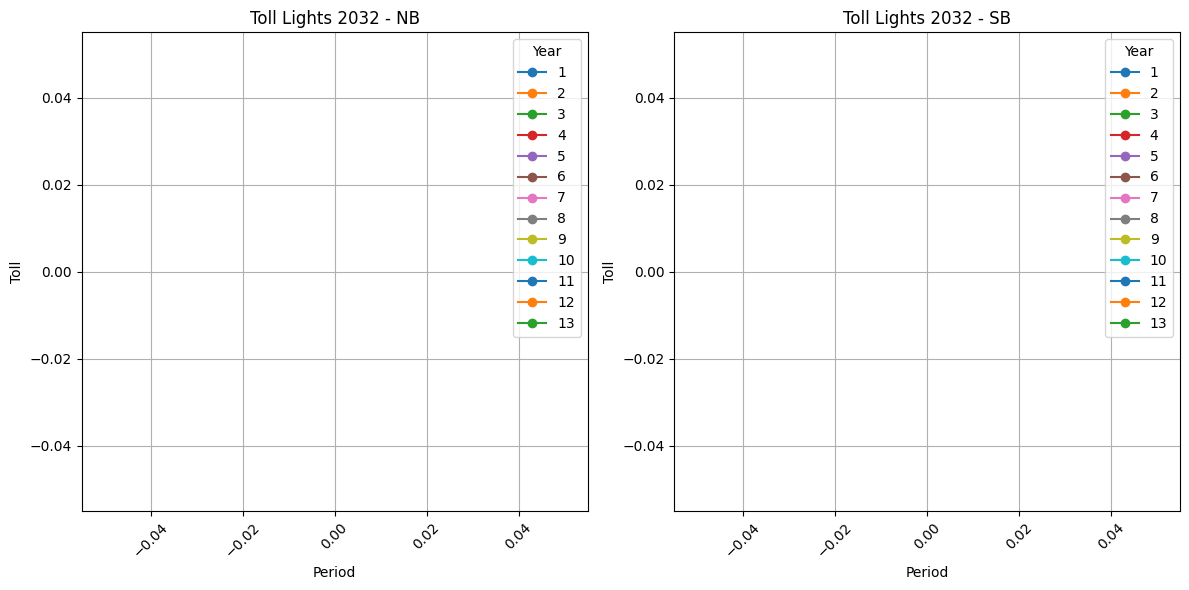

In [236]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar CSV
# model_run = pd.read_csv("outputs\\2025-09-02\\19-01-04_1\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-09-10\\18-28-56_1\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-09-12\\18-59-17_1\\model_run.csv")
model_run = pd.read_csv(f"{run_folder}\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-10-20\\GDOT_complete\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-10-17\\GDOT_base\\model_run.csv")


year_val = 2032

model_run = model_run.loc[model_run["Year"] == year_val]

# model_run.loc[model_run['Period'] == 'Night', 'TollLights'] = 0.5

# 2. Definir años y direcciones
segments = [1,2,3,4,5,6,7,8,9,10,11,12,13]
directions = ["NB", "SB"]

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    for segment in segments:
        df = model_run[(model_run["Segment"] == segment) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["TollLights"], marker='o', linestyle='-', label=str(segment))
        
    
    plt.title(f"Toll Lights {year_val} - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Toll")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

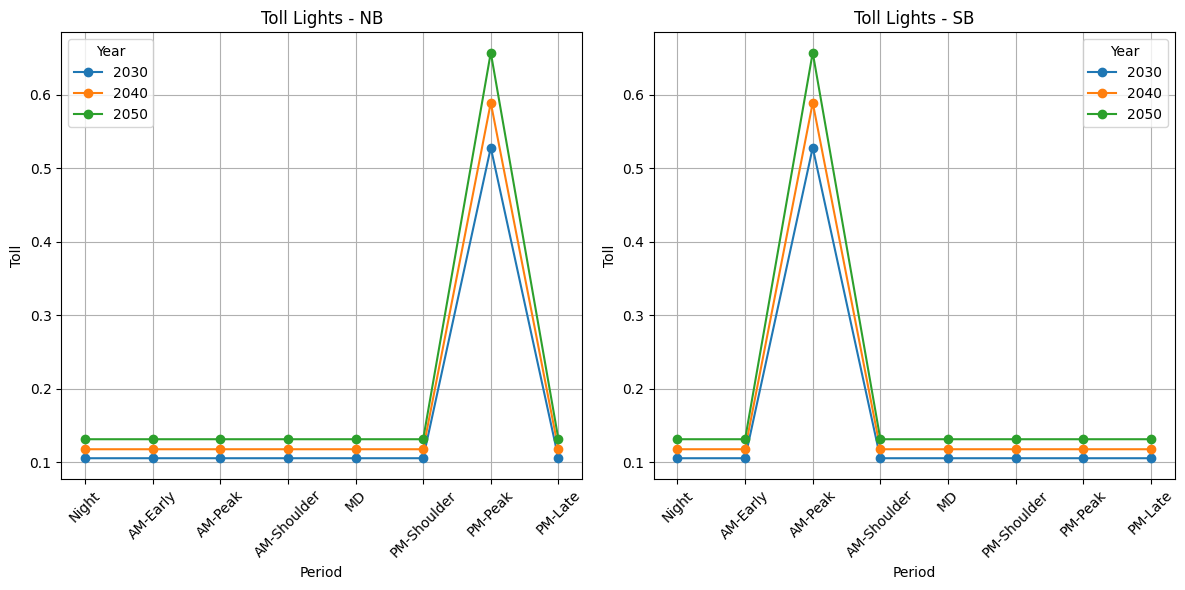

In [237]:
import pandas as pd
import matplotlib.pyplot as plt

model_run = pd.read_csv(f"{run_folder}\\model_run.csv")

# model_run = pd.read_csv("outputs\\2025-09-12\\18-59-17_1\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-10-20\\GDOT_complete\\model_run.csv")
# model_run = pd.read_csv("outputs\\2025-09-10\\18-28-56_1\\model_run.csv")
years = [2030, 2040, 2050]
directions = ["NB", "SB"]

model_run = model_run.loc[model_run["Segment"] == 6] #2

# model_run.loc[model_run['Period'] == 'Night', 'TollLights'] = 0.5

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
        
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        #if year == 2050:
        #    df["TollLights"] = df["TollLights"].clip(upper=5.15)
        #if year == 2040:
        #    df["TollLights"] = df["TollLights"].clip(upper=4.2)
        #if year == 2032:
        #    df["TollLights"] = df["TollLights"].clip(upper=3.6)

        plt.plot(df["Period"], df["TollLights"], marker='o', linestyle='-', label=str(year))
    
    df_cap_50 = pd.DataFrame({"Value": [6.86] * 8})
    df_cap_40 = pd.DataFrame({"Value": [5.63] * 8})
    df_cap_32 = pd.DataFrame({"Value": [4.62] * 8})
    # plt.plot(df["Period"], df_cap_50["Value"], marker='o', linestyle='--', color='green') 
    # plt.plot(df["Period"], df_cap_40["Value"], marker='o', linestyle='--', color='orange') 
    # plt.plot(df["Period"], df_cap_32["Value"], marker='o', linestyle='--', color='blue')
    df_cap_s50 = pd.DataFrame({"Value": [6.86/2] * 8})
    df_cap_s40 = pd.DataFrame({"Value": [5.63/2] * 8})
    df_cap_s32 = pd.DataFrame({"Value": [4.62/2] * 8})
    # plt.plot(df["Period"], df_cap_s50["Value"], marker='o', linestyle='--', color='green') 
    # plt.plot(df["Period"], df_cap_s40["Value"], marker='o', linestyle='--', color='orange') 
    # plt.plot(df["Period"], df_cap_s32["Value"], marker='o', linestyle='--', color='blue') 

    plt.title(f"Toll Lights - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Toll")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

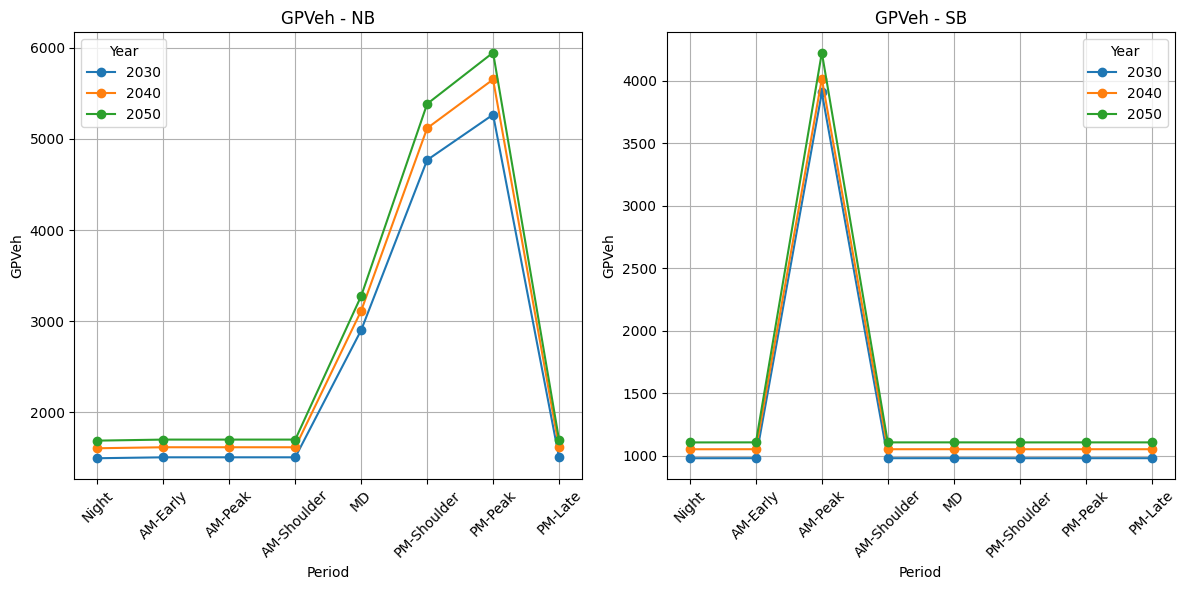

In [238]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["GPVeh"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"GPVeh - {direction}")
    plt.xlabel("Period")
    plt.ylabel("GPVeh")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

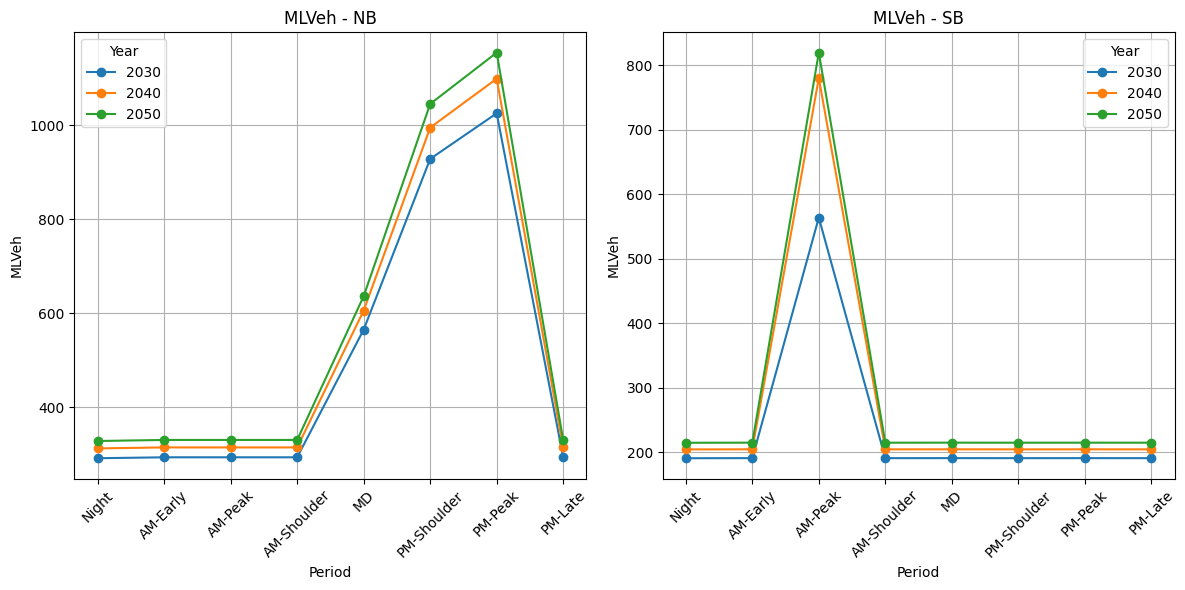

In [239]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["MLVeh"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"MLVeh - {direction}")
    plt.xlabel("Period")
    plt.ylabel("MLVeh")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

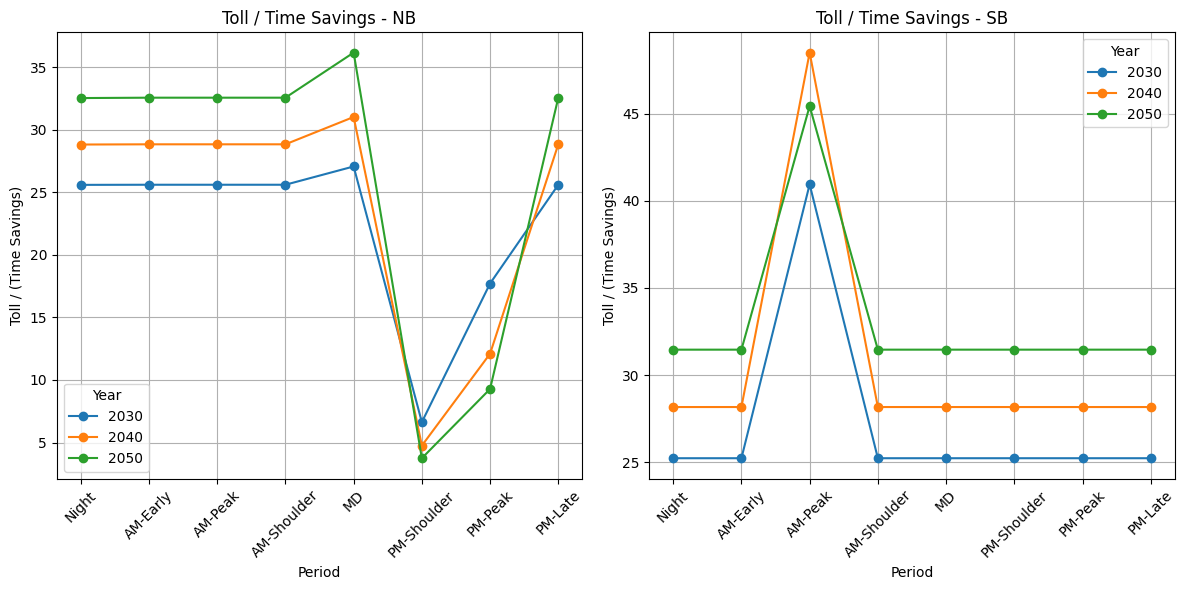

In [240]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], (60 * df["TollLights"] / (df["Time GP"] - df["Time ML"])), marker='o', linestyle='-', label=str(year))
    
    plt.title(f"Toll / Time Savings - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Toll / (Time Savings)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

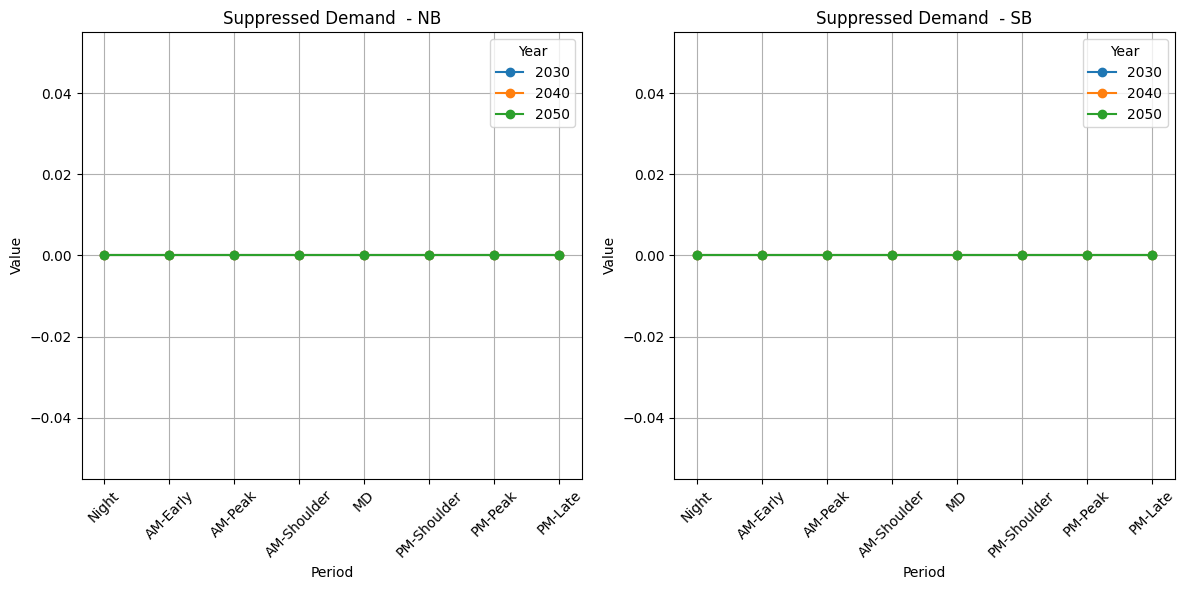

In [241]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["Suppressed Demand"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"Suppressed Demand  - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

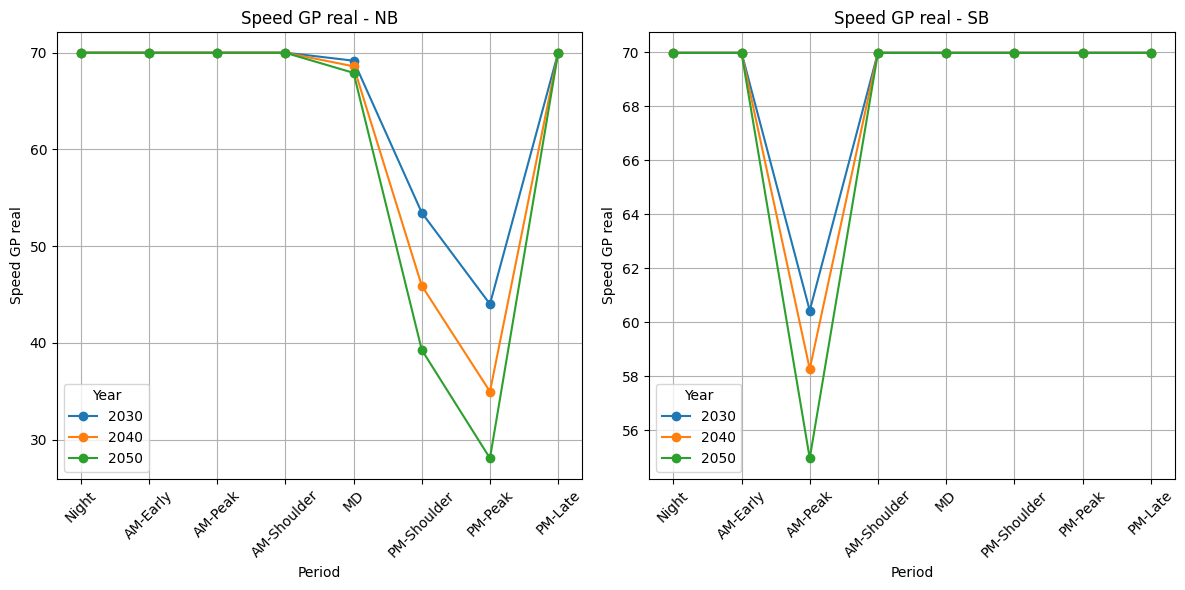

In [242]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["Speed GP Real"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"Speed GP real - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Speed GP real")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

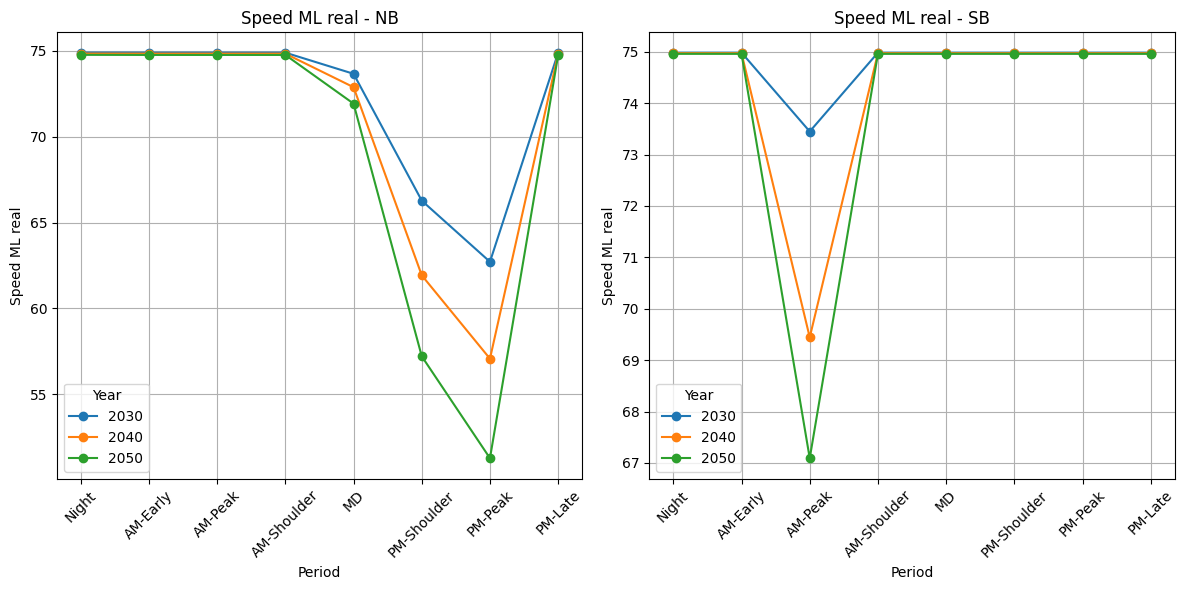

In [243]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["Speed ML Real"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"Speed ML real - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Speed ML real")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

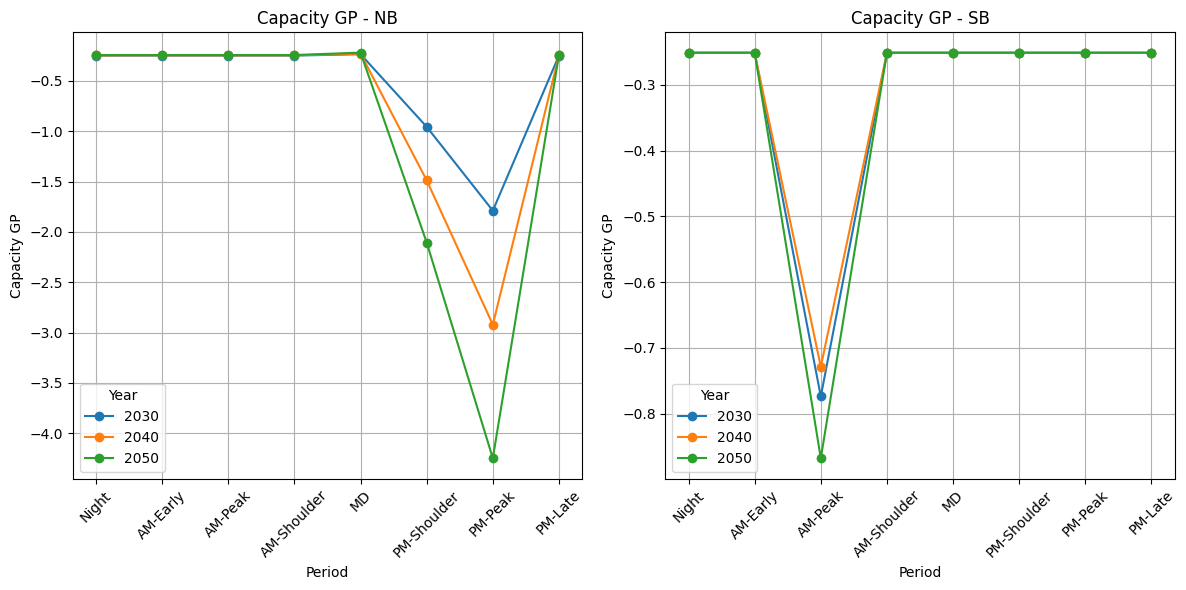

In [244]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        plt.plot(df["Period"], df["Time Savings"], marker='o', linestyle='-', label=str(year))
    
    plt.title(f"Capacity GP - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Capacity GP")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()

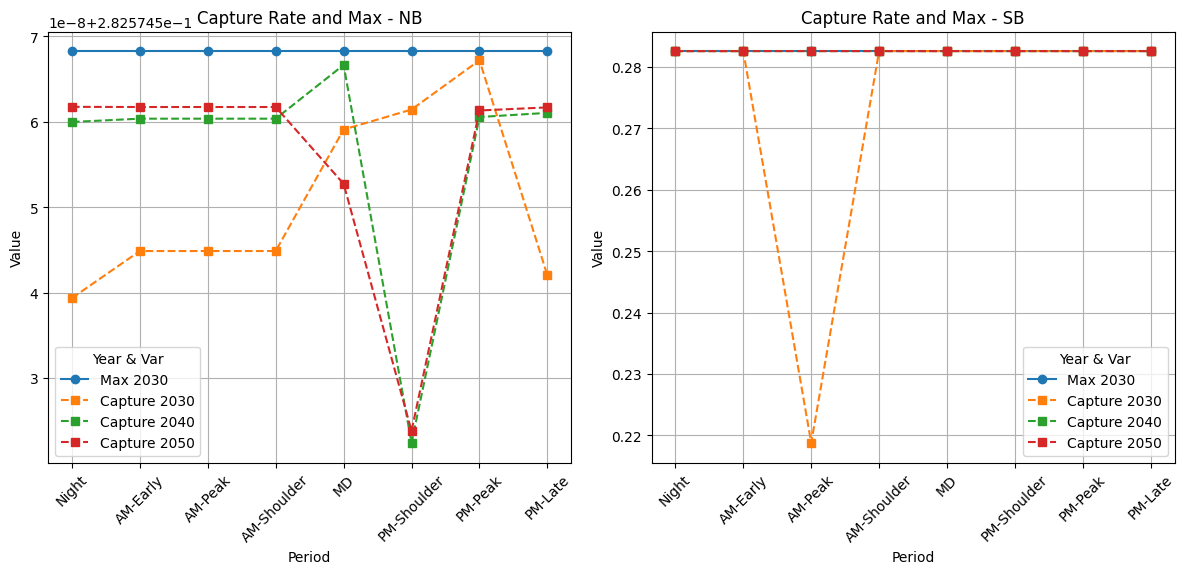

In [245]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction)]
        
        # Graficar Capture
        if year == years[0]:
            plt.plot(df["Period"], df["MaxCapture"], marker='o', linestyle='-', label=f"Max {year}")
        # Graficar Toll
        plt.plot(df["Period"], df["CaptureRateLights"], marker='s', linestyle='--', label=f"Capture {year}")
    
    plt.title(f"Capture Rate and Max - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year & Var")

plt.tight_layout()
plt.show()


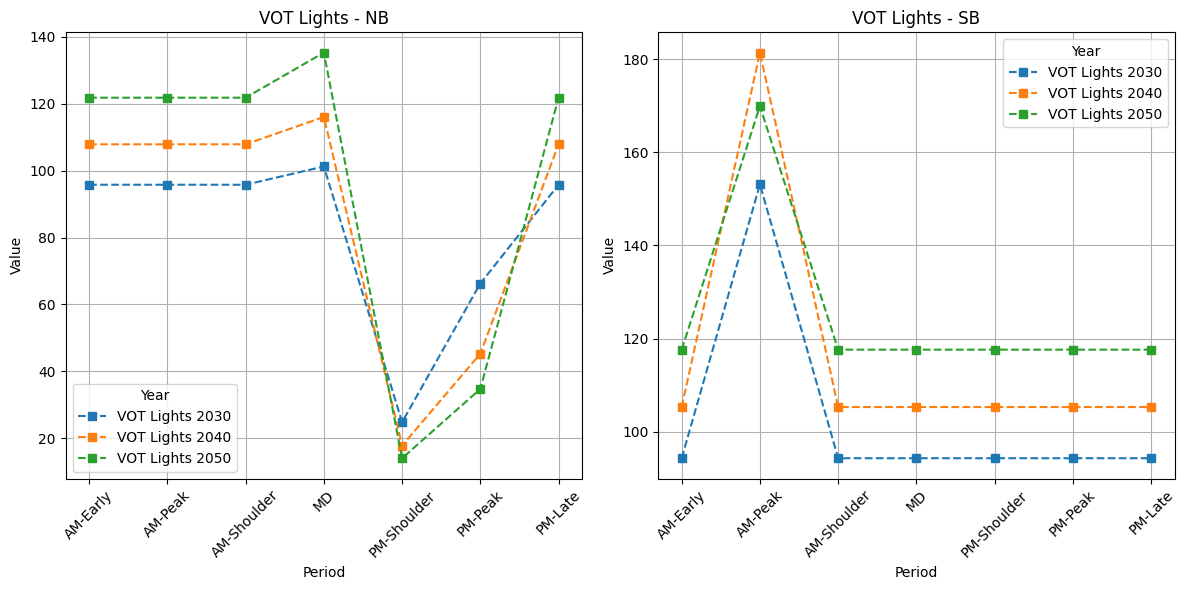

In [246]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, direction in enumerate(directions, 1):
    plt.subplot(1, 2, i)
    
    for year in years:
        df = model_run[(model_run["Year"] == year) & (model_run["Direction"] == direction) & (model_run["Period"] != "Night")]

        # Graficar Toll
        plt.plot(df["Period"], df["VOT Lights"], marker='s', linestyle='--', label=f"VOT Lights {year}")
    
    plt.title(f"VOT Lights - {direction}")
    plt.xlabel("Period")
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Year")

plt.tight_layout()
plt.show()
